In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Options: 0 = all, 1 = filter INFO, 2 = filter WARNING, 3 = ERROR only
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to True
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

2025-07-11 23:37:40.765328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752302260.774014  577018 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752302260.776904  577018 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752302260.783383  577018 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752302260.783391  577018 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752302260.783392  577018 computation_placer.cc:177] computation placer alr

In [2]:
!nvidia-smi

Fri Jul 11 23:37:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.77                 Driver Version: 565.77         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    Off |   00000000:01:00.0  On |                  N/A |
| N/A   42C    P8              3W /  115W |    1788MiB /   8188MiB |     21%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.optimizers import Adam

from IPython.display import display

In [4]:
# Custom callback to stop training after a time limit
class TimeStopping(Callback):
    def __init__(self, max_seconds=300):
        super().__init__()
        self.max_seconds = max_seconds
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.max_seconds:
            print(f"\n⏱️ Stopping training - time limit of {self.max_seconds} seconds reached.")
            self.model.stop_training = True

# Evaluation function
def eval_classification(model, X, y, name='model', labels=None):
    preds = np.rint(model.predict(X))
    print(classification_report(y, preds, target_names=labels))

    ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=labels)
    plt.show()

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

    score_df = pd.DataFrame(index=[name])
    score_df.loc[name, 'Accuracy'] = accuracy_score(y, preds)
    score_df.loc[name, 'Precision'] = precision_score(y, preds)
    score_df.loc[name, 'Recall'] = recall_score(y, preds)
    score_df.loc[name, 'F1 Score'] = f1_score(y, preds)
    score_df.loc[name, 'FPR'] = fp / (fp + tn)
    score_df.loc[name, 'FNR'] = fn / (fn + tp)

    return score_df

    
# Function to plot training history
def plot_history(history):
    """Takes a keras model learning history and plots each metric"""
    metrics = history.history.keys()
    for metric in metrics:
        if not 'val' in metric:
            plt.plot(history.history[f'{metric}'], label=f'{metric}')
            if f'val_{metric}' in metrics:
                plt.plot(history.history[f'val_{metric}'], label=f'val_{metric}')
            plt.legend()
            plt.title(f'{metric}')
            plt.xlabel('Epochs')
            plt.ylabel(metric.capitalize())
            plt.grid(True)
            plt.show()


### Classification:
To evaluate the model's performance, the F1 Score is used. It is suitable for phishing detection because it strikes a balance between precision and recall, considering both false positives and false negatives, rather than focusing on one aspect alone. Unlike accuracy, it treats imbalanced datasets well and prevents incorrect performance conclusions. By encapsulating both types of error within a single metric, F1 provides a better understanding of the model's performance and confidence.

### Pseudo Code

FOR each layer_config in layer_configs:
  FOR each epoch_count in epochs_list:
    FOR each min_delta in min_deltas:
      FOR each patience_value in patiences:
        Build sequential model
        Add input + hidden layers with relu
        Add sigmoid output layer
        Compile with Adam, binary_crossentropy
        Apply EarlyStopping + TimeStopping
        Train on X_train, validate on X_val
        Evaluate on both sets using F1 Score, Accuracy, Precision, Recall
        If best F1, save model and config


In [5]:
df_train = pd.read_csv('Split_Data/Model_Ready/train.csv')
df_train.head()
# Define X and y and train data
X_train = df_train.drop(columns = 'label')
y_train = df_train['label']

df_val = pd.read_csv('Split_Data/Model_Ready/val.csv')

# Define X and y and train data
X_val = df_val.drop(columns = 'label')
y_val = df_val['label']

### Build de Model

In [6]:
# ---------------------------------------------------------
# Define hyperparameter search space for grid search
# ---------------------------------------------------------

# Each entry in `layer_configs` is a list representing the number of neurons in each hidden layer
layer_configs = [[64], [128, 64], [256, 128, 64]]

# Number of epochs (maximum) to allow during training
epochs_list = [50, 100]

# Minimum change in validation loss to qualify as an improvement
# Used by the EarlyStopping callback to determine convergence
min_deltas = [0.0, 0.001]

# Number of epochs to wait after no improvement before stopping early
patiences = [1, 3, 5]

# ---------------------------------------------------------
# Initialize tracking variables to record the best model run
# ---------------------------------------------------------

# Collect all evaluation metrics (train/val scores) across all configurations
all_scores = []

# Best F1 score seen so far (used to determine the top-performing model)
best_f1 = -1

# Store the best Keras model instance
best_model = None

# Store the training history of the best model (for plotting)
best_history = None

# Store the hyperparameter configuration of the best model
best_config = None


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1752302273.005162  577018 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4309 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



Config: layers=[64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


I0000 00:00:1752302273.746405  577195 service.cc:152] XLA service 0x7bd898004a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752302273.746426  577195 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
I0000 00:00:1752302273.820231  577195 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1752302273.954366  577195 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1650/1650 - 3s - 2ms/step - accuracy: 0.9610 - loss: 0.1076 - val_accuracy: 0.9763 - val_loss: 0.0702
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9815 - loss: 0.0534 - val_accuracy: 0.9817 - val_loss: 0.0569
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9864 - loss: 0.0409 - val_accuracy: 0.9835 - val_loss: 0.0533
Epoch 4/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9891 - loss: 0.0326 - val_accuracy: 0.9838 - val_loss: 0.0645
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.0533, stopped at epoch 4

Print History


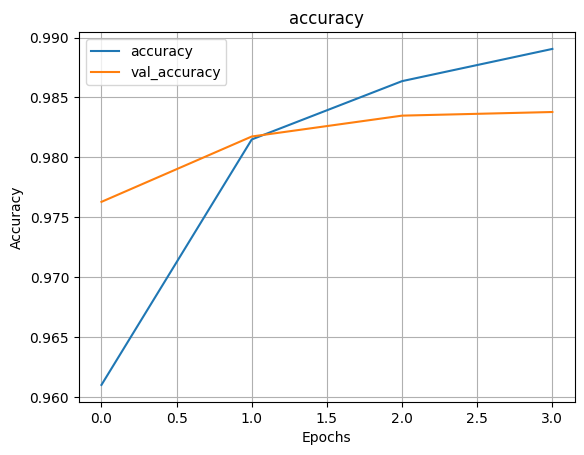

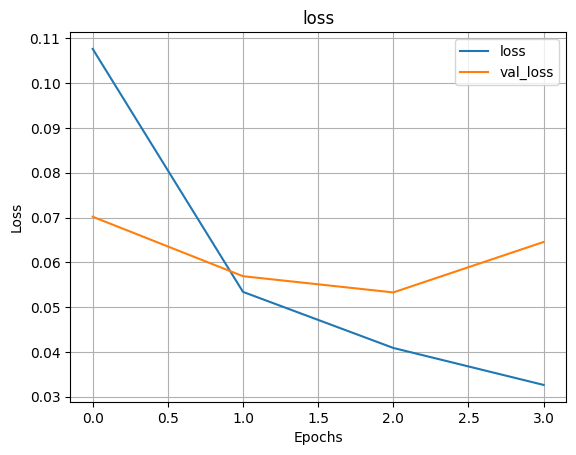

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



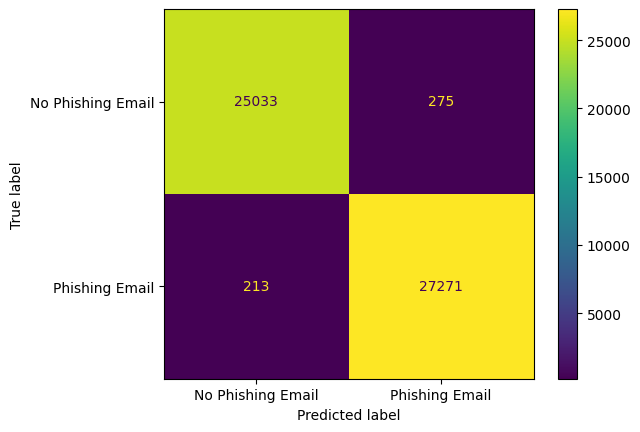

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



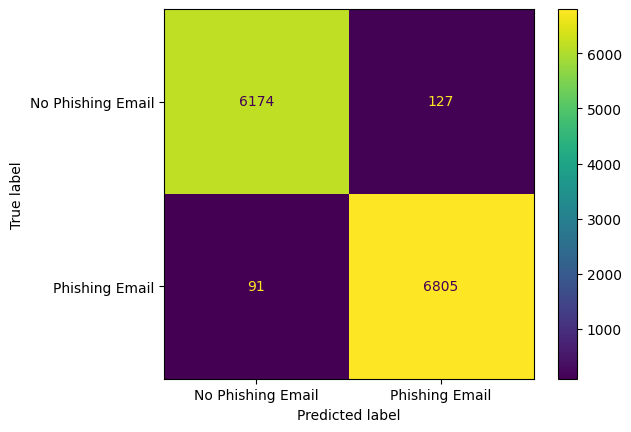


Config: layers=[64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9633 - loss: 0.1038 - val_accuracy: 0.9764 - val_loss: 0.0681
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9821 - loss: 0.0525 - val_accuracy: 0.9825 - val_loss: 0.0512
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9862 - loss: 0.0405 - val_accuracy: 0.9849 - val_loss: 0.0496
Epoch 4/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9890 - loss: 0.0332 - val_accuracy: 0.9841 - val_loss: 0.0491
Epoch 5/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9916 - loss: 0.0274 - val_accuracy: 0.9851 - val_loss: 0.0505
Epoch 6/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9928 - loss: 0.0235 - val_accuracy: 0.9852 - val_loss: 0.0529
Epoch 7/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9942 - loss: 0.0200 - val_accuracy: 0.9839 - val_loss: 0.0562
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Finished. Best val_loss=0.0491, stopped at epoch 7

Print History


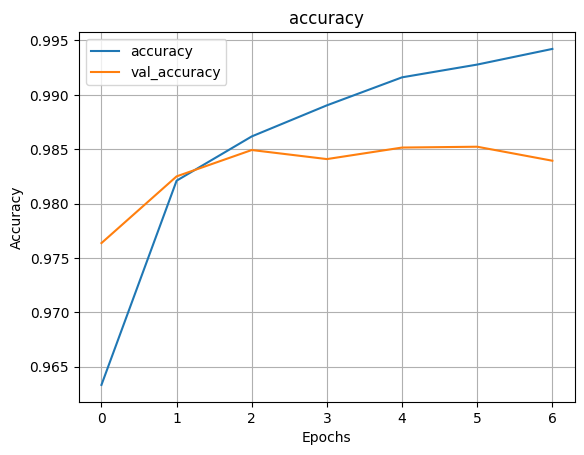

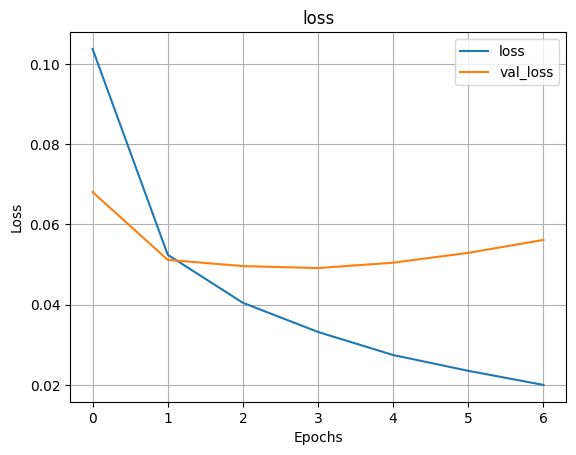

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 438us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



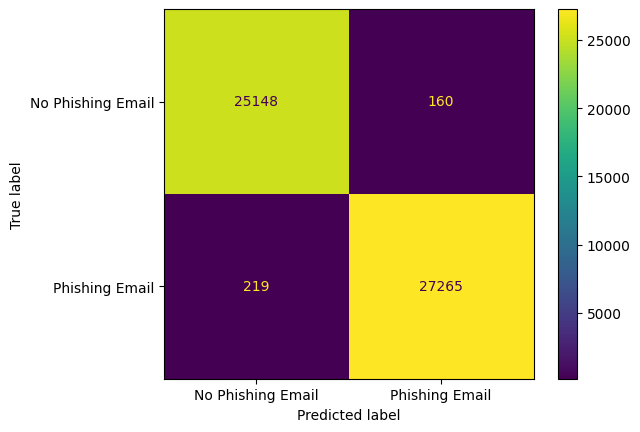

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



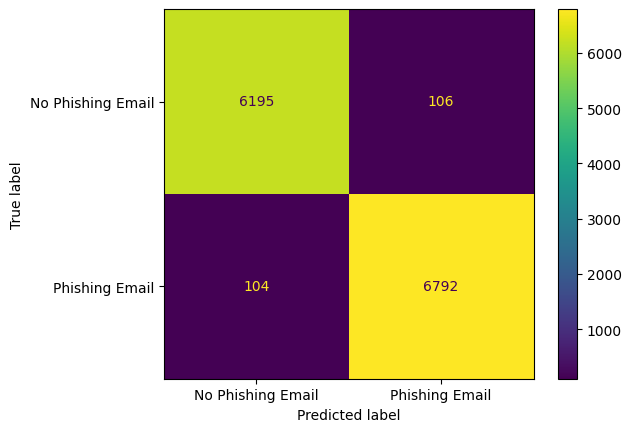


Config: layers=[64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9594 - loss: 0.1105 - val_accuracy: 0.9773 - val_loss: 0.0663
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9818 - loss: 0.0523 - val_accuracy: 0.9825 - val_loss: 0.0535
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9860 - loss: 0.0406 - val_accuracy: 0.9830 - val_loss: 0.0480
Epoch 4/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9889 - loss: 0.0335 - val_accuracy: 0.9841 - val_loss: 0.0540
Epoch 5/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9912 - loss: 0.0260 - val_accuracy: 0.9847 - val_loss: 0.0529
Epoch 6/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9926 - loss: 0.0235 - val_accuracy: 0.9848 - val_loss: 0.0512
Epoch 7/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9943 - loss: 0.0182 - val_accuracy: 0.9855 - val_loss: 0.0517
Epoch 8/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9951 - loss: 0.0173 - val_accuracy: 0.9836 - val_loss: 0.0589
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=

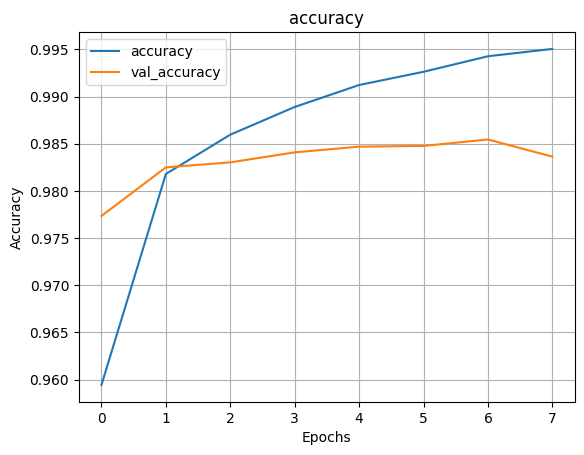

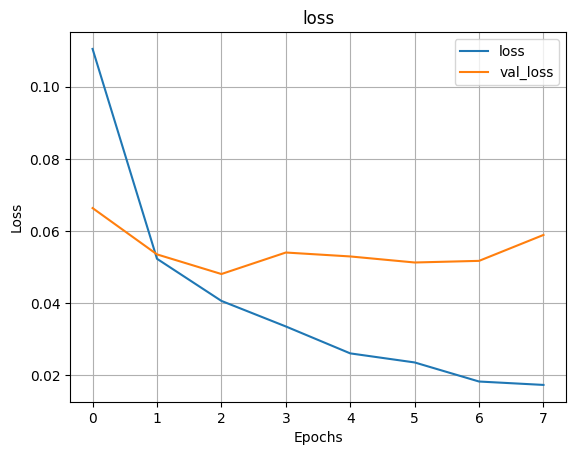

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 416us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



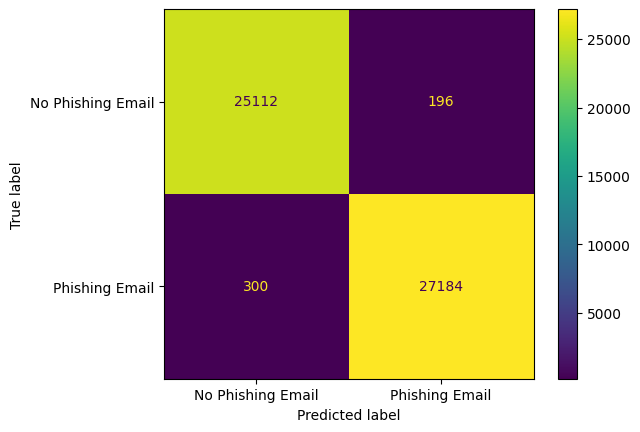

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



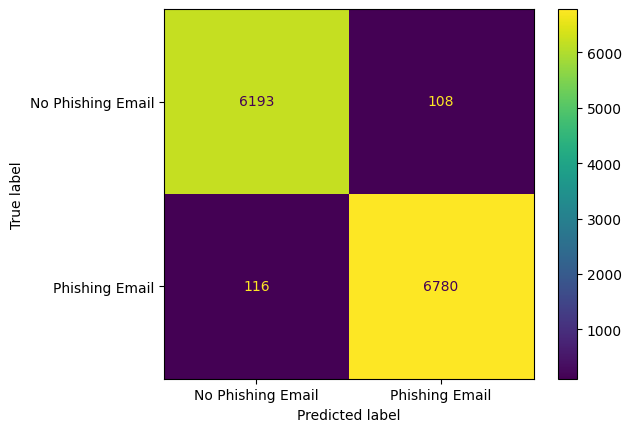


Config: layers=[64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9600 - loss: 0.1102 - val_accuracy: 0.9751 - val_loss: 0.1103
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9819 - loss: 0.0518 - val_accuracy: 0.9819 - val_loss: 0.0567
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9864 - loss: 0.0414 - val_accuracy: 0.9800 - val_loss: 0.0859
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0567, stopped at epoch 3

Print History


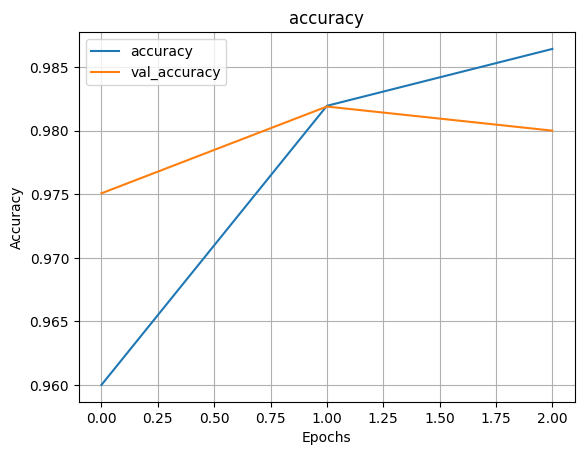

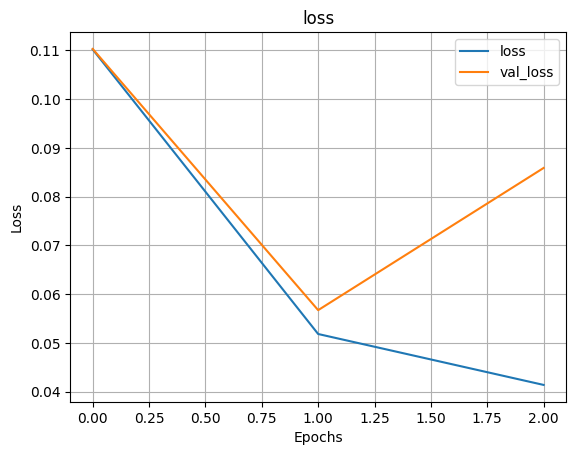

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



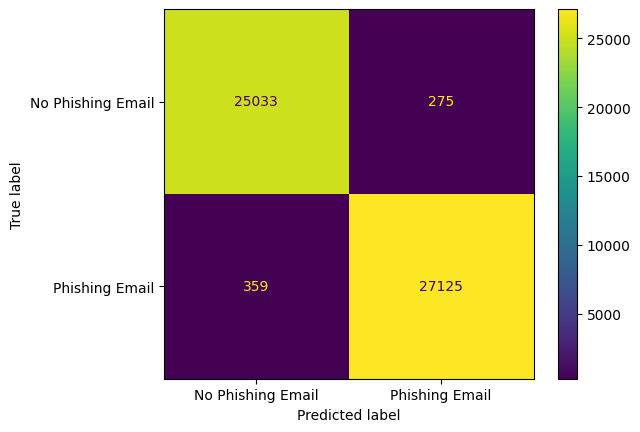

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



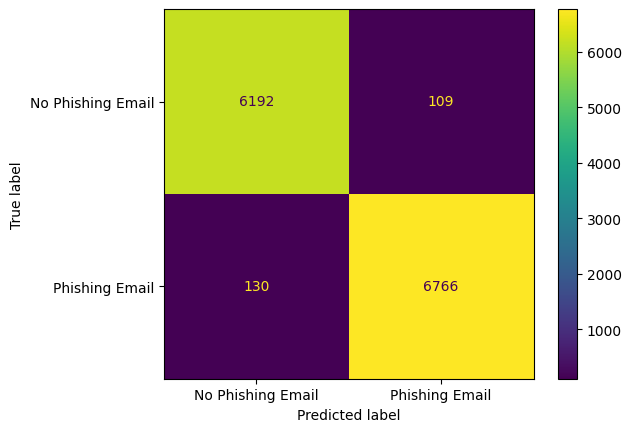


Config: layers=[64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9608 - loss: 0.1100 - val_accuracy: 0.9789 - val_loss: 0.0670
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9816 - loss: 0.0536 - val_accuracy: 0.9761 - val_loss: 0.1378
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9869 - loss: 0.0400 - val_accuracy: 0.9805 - val_loss: 0.0629
Epoch 4/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9887 - loss: 0.0334 - val_accuracy: 0.9818 - val_loss: 0.0676
Epoch 5/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9915 - loss: 0.0278 - val_accuracy: 0.9824 - val_loss: 0.1035
Epoch 6/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9932 - loss: 0.0213 - val_accuracy: 0.9847 - val_loss: 0.0524
Epoch 7/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9937 - loss: 0.0195 - val_accuracy: 0.9855 - val_loss: 0.0515
Epoch 8/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9950 - loss: 0.0157 - val_accuracy: 0.9860 - val_loss: 0.0562
Epoch 9/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9960 - loss: 0.0150 - val_accuracy: 0.9824 - val_loss: 0

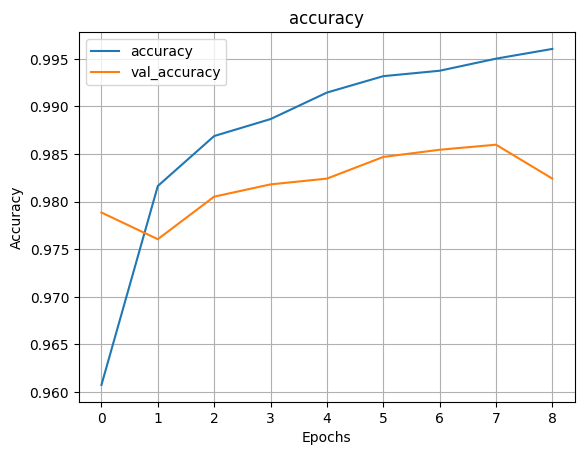

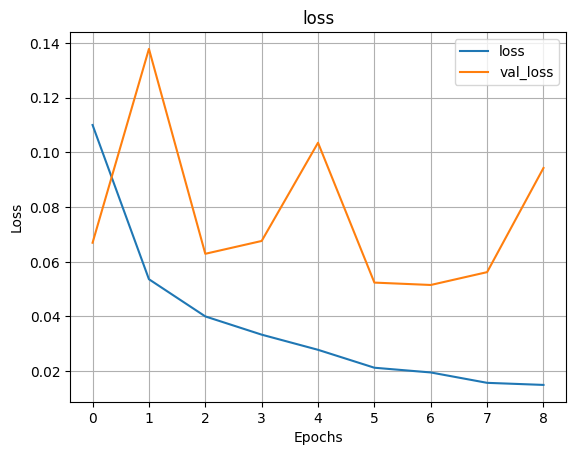

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 393us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      1.00      0.99     25308
   Phishing Email       1.00      0.99      1.00     27484

         accuracy                           1.00     52792
        macro avg       1.00      1.00      1.00     52792
     weighted avg       1.00      1.00      1.00     52792



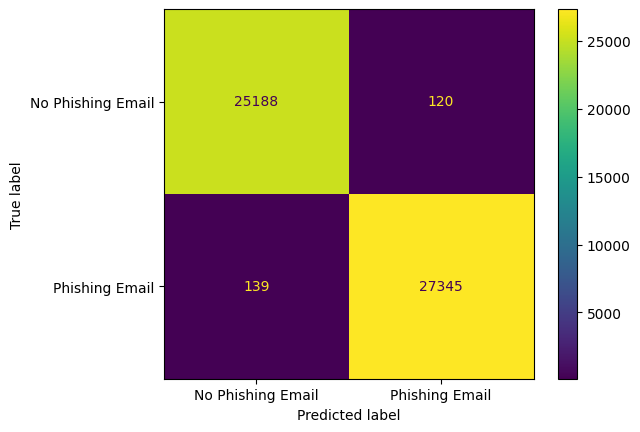

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



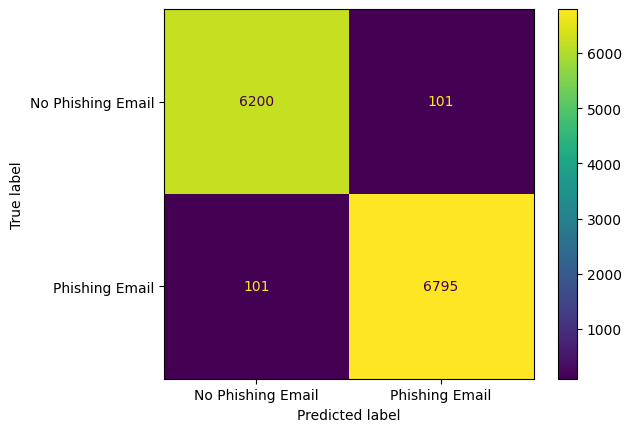


Config: layers=[64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9616 - loss: 0.1053 - val_accuracy: 0.9751 - val_loss: 0.0727
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9818 - loss: 0.0533 - val_accuracy: 0.9801 - val_loss: 0.0715
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9864 - loss: 0.0414 - val_accuracy: 0.9807 - val_loss: 0.0646
Epoch 4/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9887 - loss: 0.0347 - val_accuracy: 0.9844 - val_loss: 0.0496
Epoch 5/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9912 - loss: 0.0279 - val_accuracy: 0.9848 - val_loss: 0.0500
Epoch 6/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9932 - loss: 0.0232 - val_accuracy: 0.9847 - val_loss: 0.0516
Epoch 7/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9941 - loss: 0.0207 - val_accuracy: 0.9825 - val_loss: 0.0564
Epoch 8/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9956 - loss: 0.0152 - val_accuracy: 0.9847 - val_loss: 0.0630
Epoch 9/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9957 - loss: 0.0143 - val_accuracy: 0.9846 - val_loss: 0

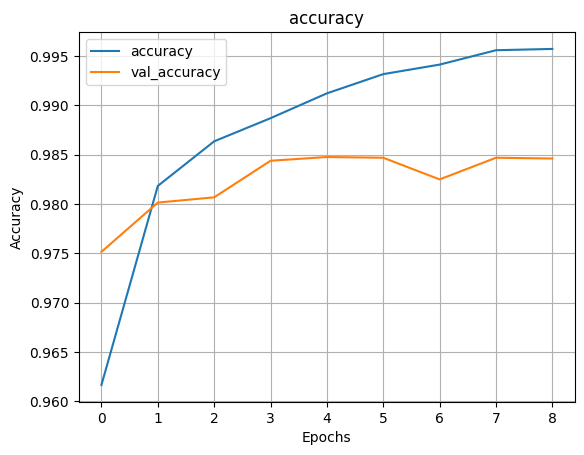

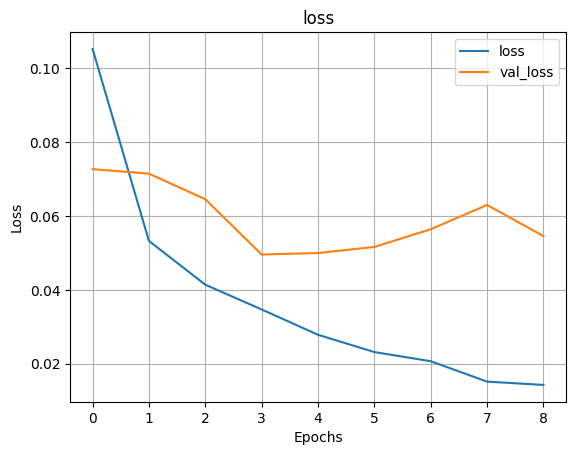

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 502us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      1.00      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



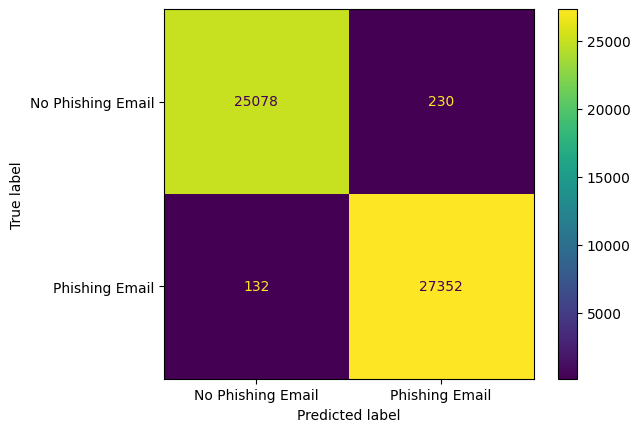

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.99      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



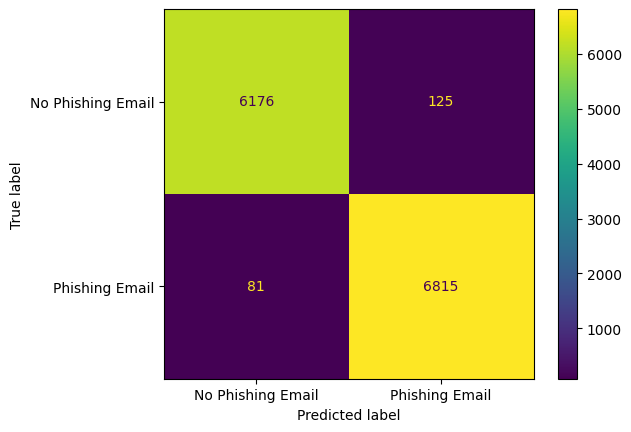


Config: layers=[64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9618 - loss: 0.1043 - val_accuracy: 0.9754 - val_loss: 0.0717
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9825 - loss: 0.0520 - val_accuracy: 0.9817 - val_loss: 0.0560
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9864 - loss: 0.0398 - val_accuracy: 0.9806 - val_loss: 0.0641
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0560, stopped at epoch 3

Print History


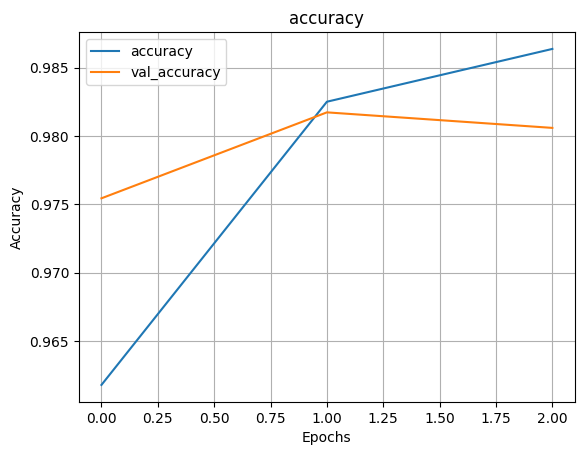

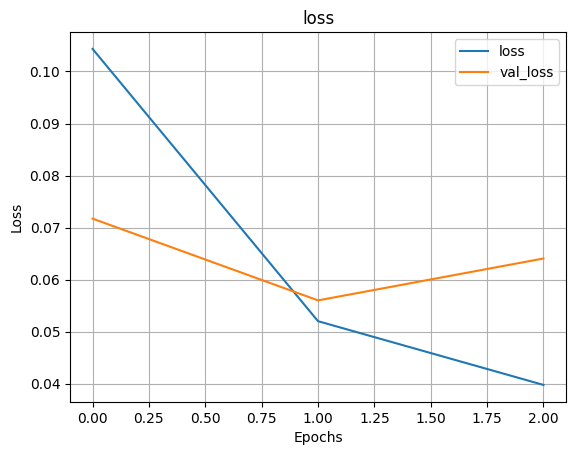

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 462us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



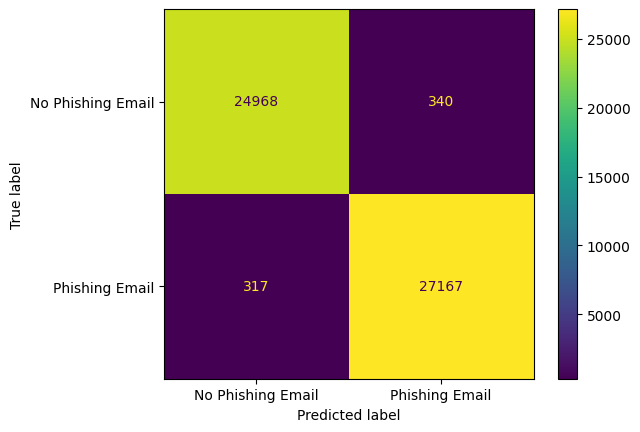

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



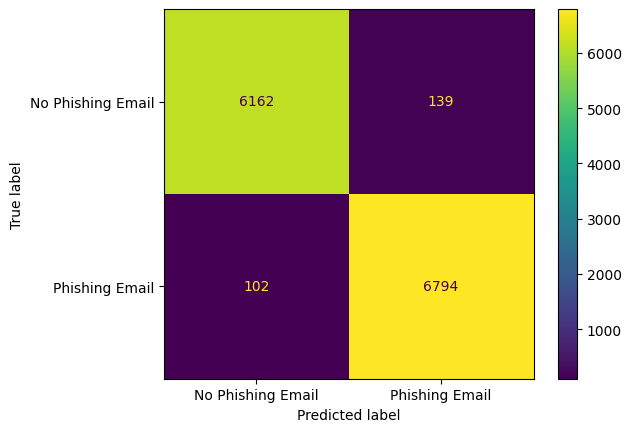


Config: layers=[64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9601 - loss: 0.1081 - val_accuracy: 0.9787 - val_loss: 0.0640
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9822 - loss: 0.0530 - val_accuracy: 0.9814 - val_loss: 0.0582
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9863 - loss: 0.0409 - val_accuracy: 0.9814 - val_loss: 0.0550
Epoch 4/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9890 - loss: 0.0334 - val_accuracy: 0.9852 - val_loss: 0.0478
Epoch 5/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9914 - loss: 0.0271 - val_accuracy: 0.9845 - val_loss: 0.0536
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9927 - loss: 0.0241 - val_accuracy: 0.9844 - val_loss: 0.0586
Epoch 7/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9938 - loss: 0.0200 - val_accuracy: 0.9864 - val_loss: 0.0519
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Finished. Best val_loss=0.0478, stopped at epoch 7

Print History


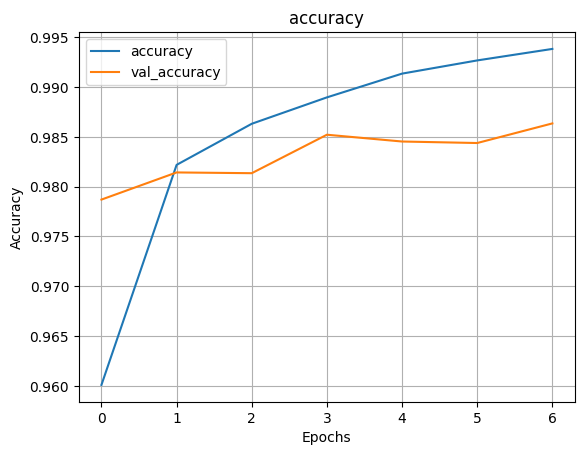

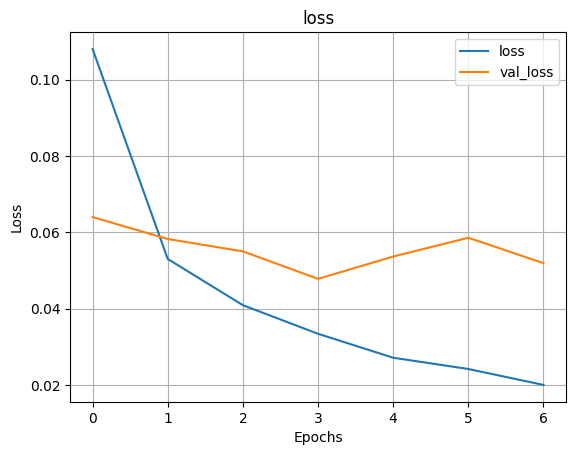

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



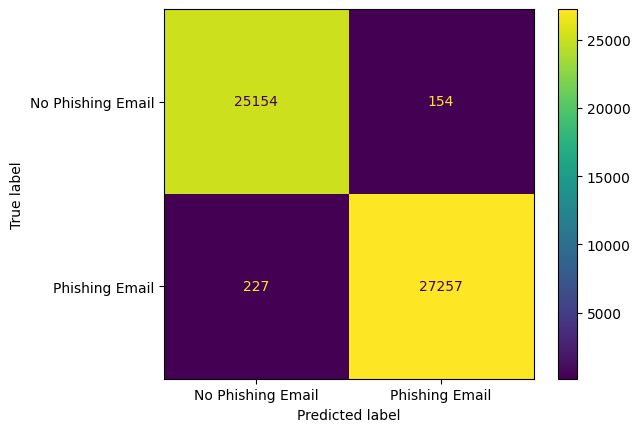

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



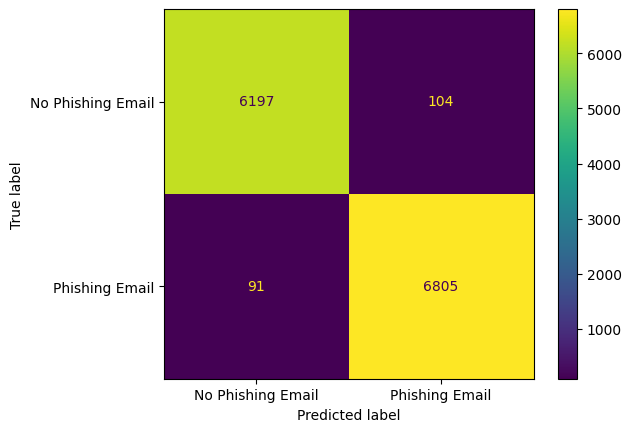


Config: layers=[64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9613 - loss: 0.1057 - val_accuracy: 0.9742 - val_loss: 0.0715
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9818 - loss: 0.0519 - val_accuracy: 0.9811 - val_loss: 0.0581
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9865 - loss: 0.0391 - val_accuracy: 0.9806 - val_loss: 0.0564
Epoch 4/100
1650/1650 - 2s - 983us/step - accuracy: 0.9889 - loss: 0.0330 - val_accuracy: 0.9838 - val_loss: 0.0527
Epoch 5/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9914 - loss: 0.0262 - val_accuracy: 0.9826 - val_loss: 0.0579
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9931 - loss: 0.0226 - val_accuracy: 0.9848 - val_loss: 0.0519
Epoch 7/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9941 - loss: 0.0212 - val_accuracy: 0.9842 - val_loss: 0.0587
Epoch 8/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9952 - loss: 0.0156 - val_accuracy: 0.9858 - val_loss: 0.0557
Epoch 9/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9962 - loss: 0.0145 - val_accuracy: 0.9851 - v

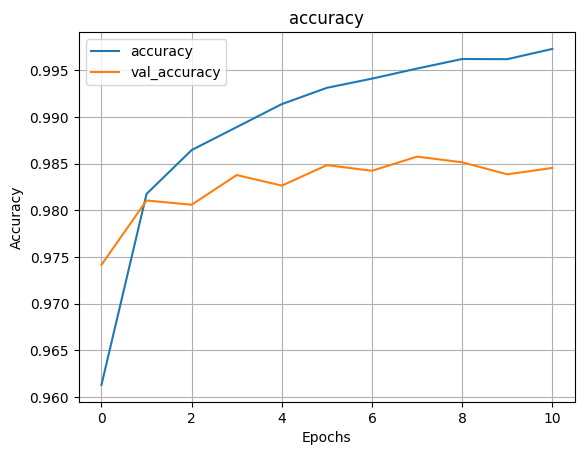

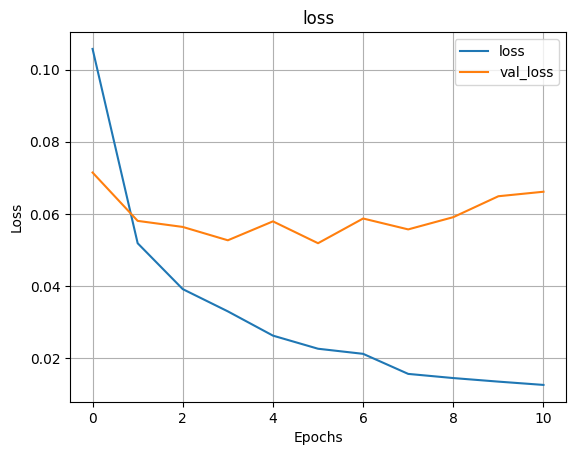

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 596us/step
                   precision    recall  f1-score   support

No Phishing Email       1.00      1.00      1.00     25308
   Phishing Email       1.00      1.00      1.00     27484

         accuracy                           1.00     52792
        macro avg       1.00      1.00      1.00     52792
     weighted avg       1.00      1.00      1.00     52792



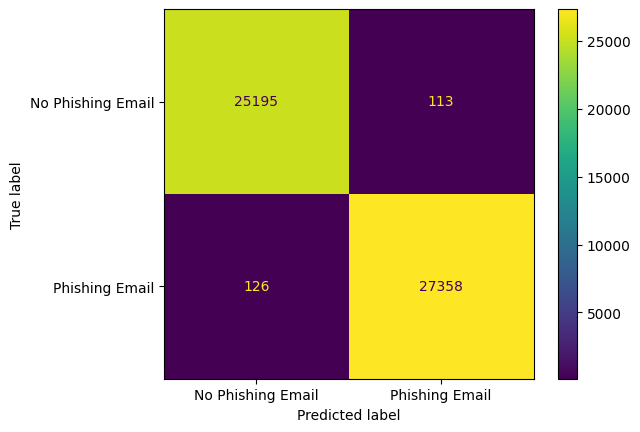

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



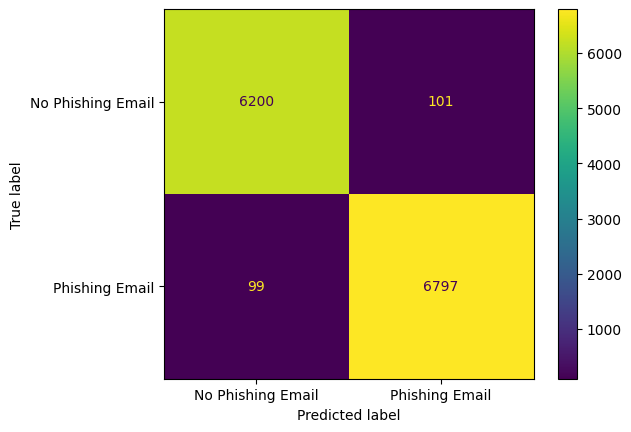


Config: layers=[64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9611 - loss: 0.1041 - val_accuracy: 0.9778 - val_loss: 0.0642
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9814 - loss: 0.0549 - val_accuracy: 0.9814 - val_loss: 0.0546
Epoch 3/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9859 - loss: 0.0420 - val_accuracy: 0.9792 - val_loss: 0.0824
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0546, stopped at epoch 3

Print History


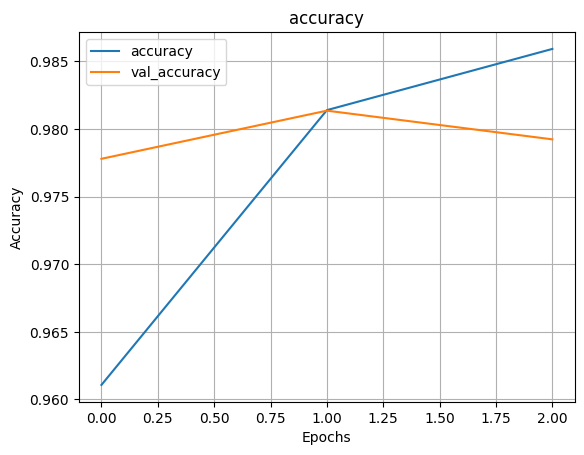

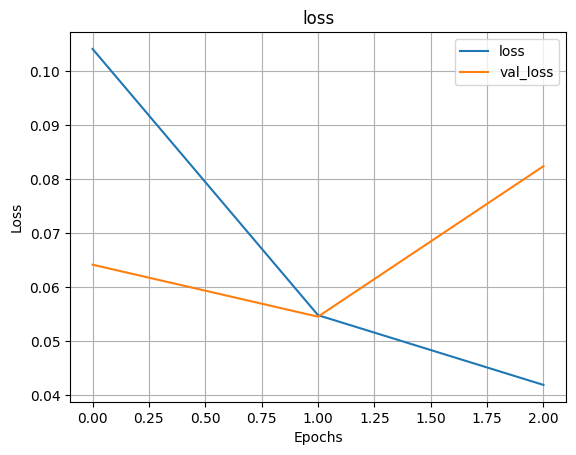

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 625us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.99     25308
   Phishing Email       0.98      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



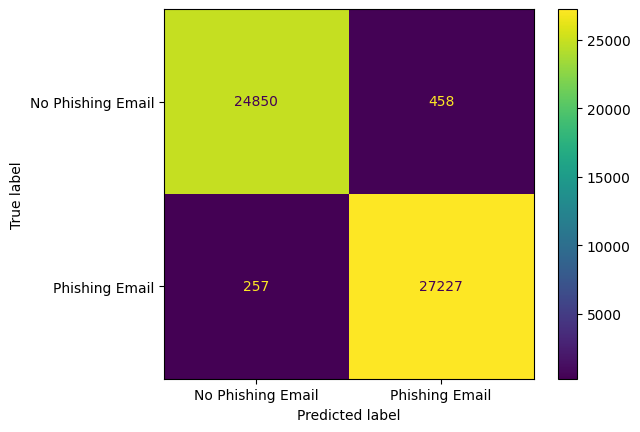

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.97      0.98      6301
   Phishing Email       0.98      0.99      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



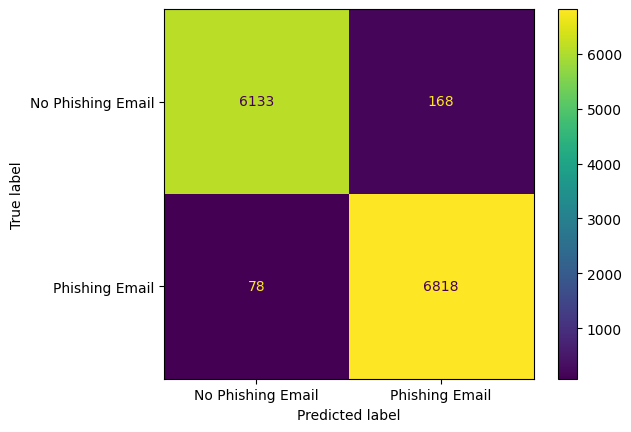


Config: layers=[64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9625 - loss: 0.1045 - val_accuracy: 0.9782 - val_loss: 0.0625
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9812 - loss: 0.0538 - val_accuracy: 0.9802 - val_loss: 0.0553
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9858 - loss: 0.0415 - val_accuracy: 0.9823 - val_loss: 0.0591
Epoch 4/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9887 - loss: 0.0368 - val_accuracy: 0.9843 - val_loss: 0.0553
Epoch 5/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9906 - loss: 0.0291 - val_accuracy: 0.9836 - val_loss: 0.0506
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9924 - loss: 0.0224 - val_accuracy: 0.9858 - val_loss: 0.0487
Epoch 7/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9937 - loss: 0.0217 - val_accuracy: 0.9846 - val_loss: 0.0512
Epoch 8/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9946 - loss: 0.0183 - val_accuracy: 0.9861 - val_loss: 0.0503
Epoch 9/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9956 - loss: 0.0158 - val_accuracy: 0.9851 - val

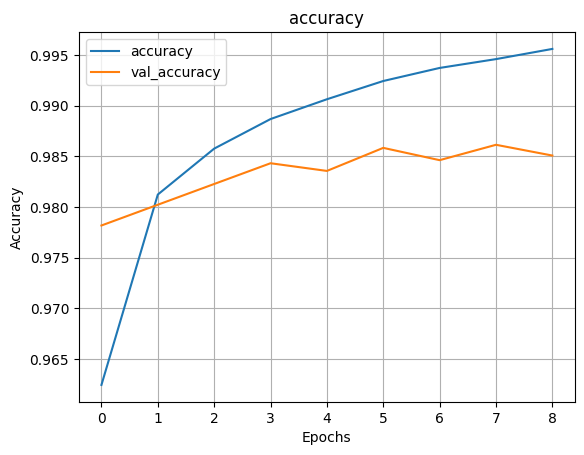

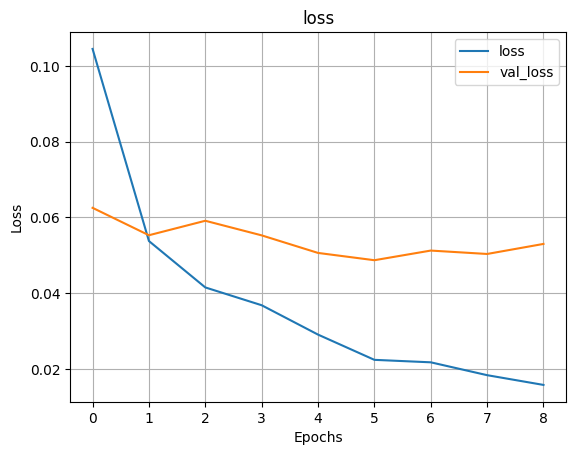

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 484us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      1.00      0.99     25308
   Phishing Email       1.00      0.99      1.00     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



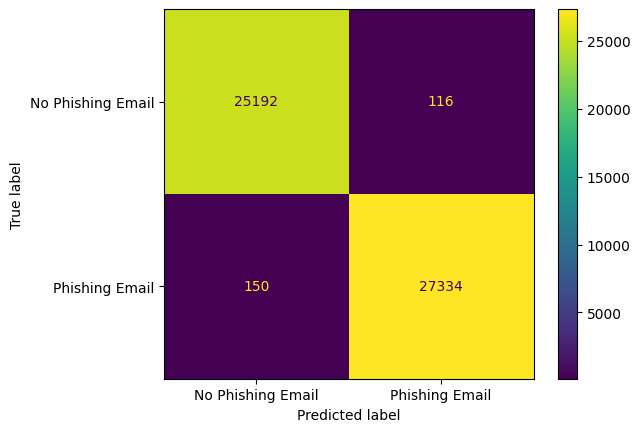

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.99      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



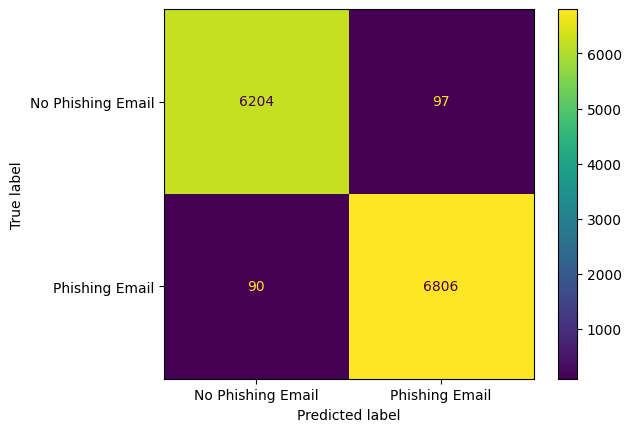


Config: layers=[64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9621 - loss: 0.1034 - val_accuracy: 0.9750 - val_loss: 0.0685
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9823 - loss: 0.0520 - val_accuracy: 0.9814 - val_loss: 0.0581
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9864 - loss: 0.0401 - val_accuracy: 0.9833 - val_loss: 0.0555
Epoch 4/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9895 - loss: 0.0335 - val_accuracy: 0.9826 - val_loss: 0.0556
Epoch 5/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9912 - loss: 0.0259 - val_accuracy: 0.9828 - val_loss: 0.0585
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9930 - loss: 0.0221 - val_accuracy: 0.9851 - val_loss: 0.0557
Epoch 7/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9943 - loss: 0.0212 - val_accuracy: 0.9845 - val_loss: 0.0579
Epoch 8/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9952 - loss: 0.0165 - val_accuracy: 0.9849 - val_loss: 0.0581
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best va

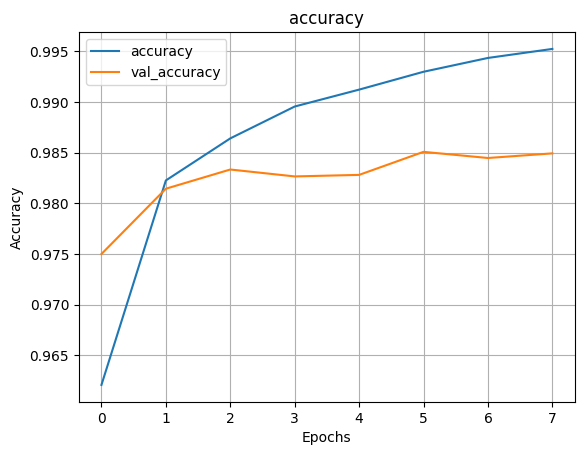

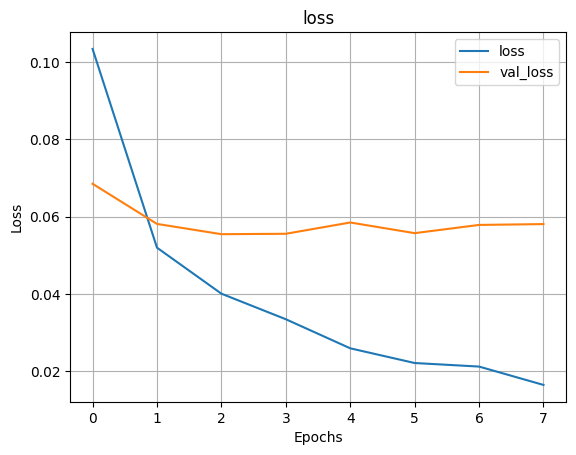

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 417us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



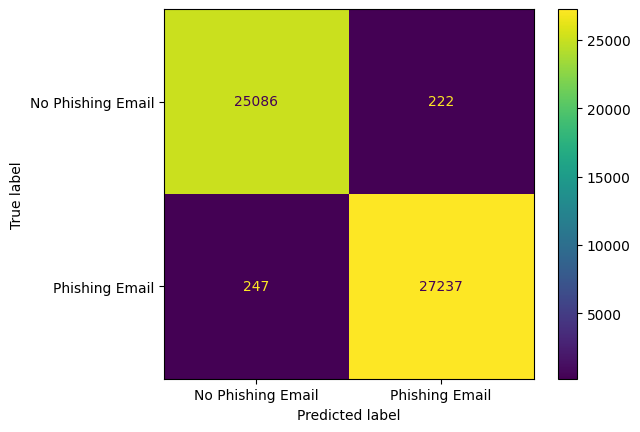

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



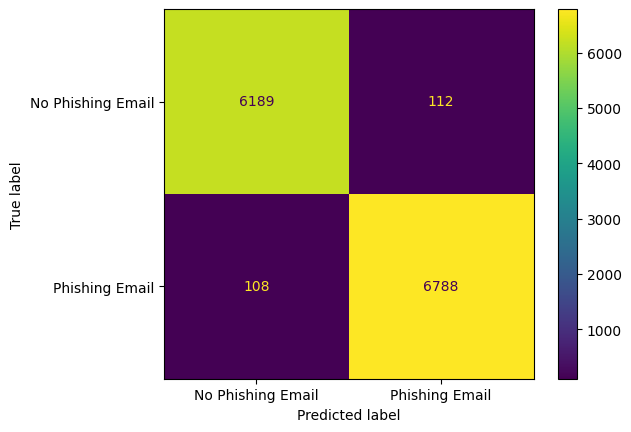


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 5s - 3ms/step - accuracy: 0.9694 - loss: 0.0867 - val_accuracy: 0.9804 - val_loss: 0.0567
Epoch 2/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9857 - loss: 0.0414 - val_accuracy: 0.9779 - val_loss: 0.0675
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.0567, stopped at epoch 2

Print History


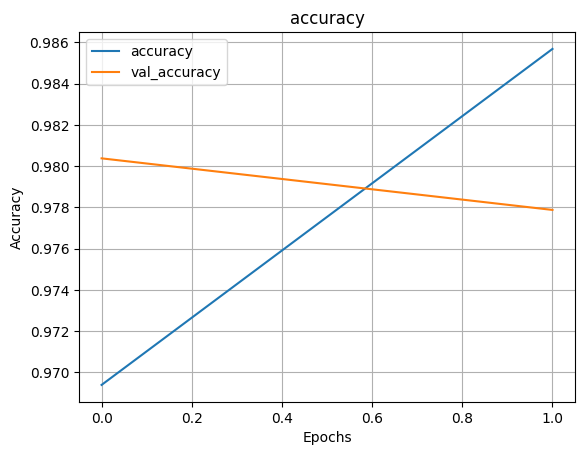

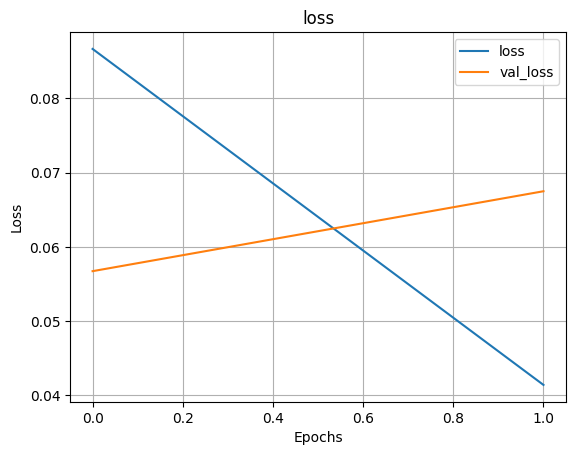

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 462us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.99      0.99     25308
   Phishing Email       0.99      0.98      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



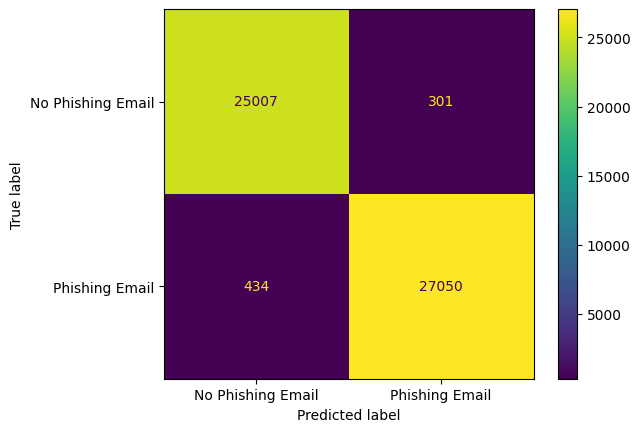

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



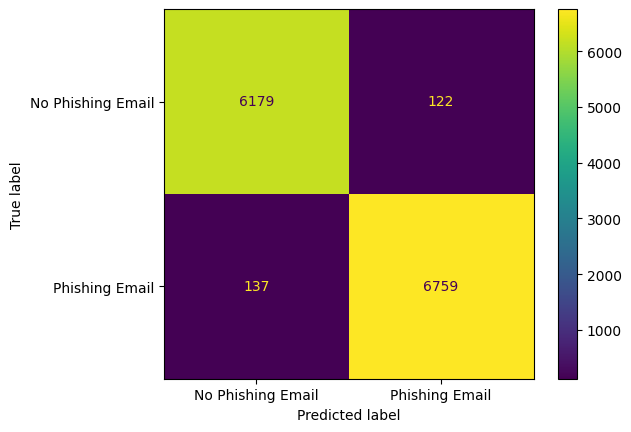


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 2ms/step - accuracy: 0.9666 - loss: 0.0921 - val_accuracy: 0.9701 - val_loss: 0.1015
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9848 - loss: 0.0439 - val_accuracy: 0.9811 - val_loss: 0.0544
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9890 - loss: 0.0323 - val_accuracy: 0.9841 - val_loss: 0.0531
Epoch 4/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9916 - loss: 0.0248 - val_accuracy: 0.9844 - val_loss: 0.0485
Epoch 5/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9939 - loss: 0.0176 - val_accuracy: 0.9844 - val_loss: 0.0559
Epoch 6/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9949 - loss: 0.0142 - val_accuracy: 0.9856 - val_loss: 0.0502
Epoch 7/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9959 - loss: 0.0115 - val_accuracy: 0.9857 - val_loss: 0.0587
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Finished. Best val_loss=0.0485, stopped at epoch 7

Print History


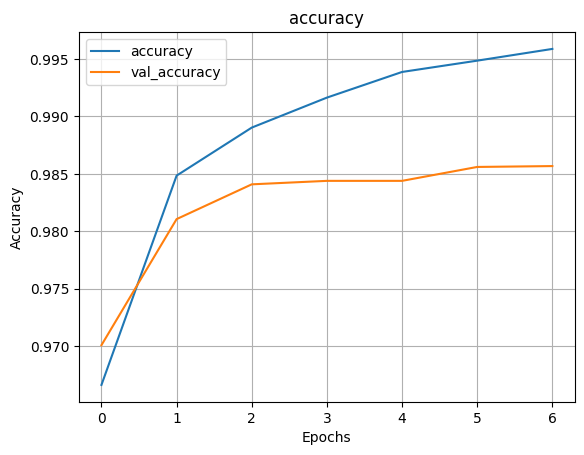

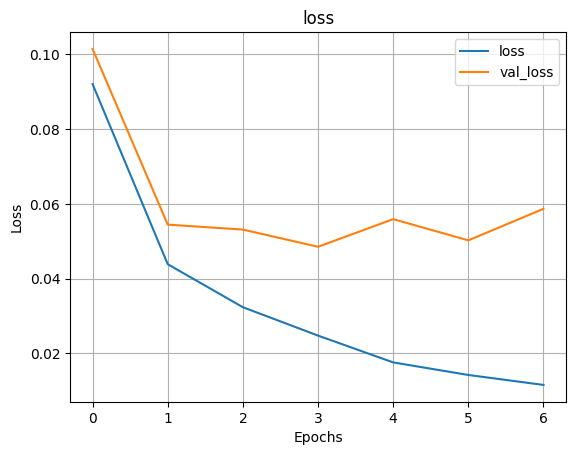

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 544us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      1.00      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



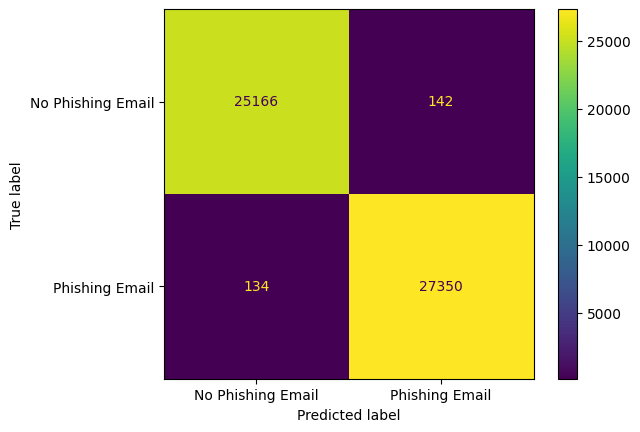

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.99      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



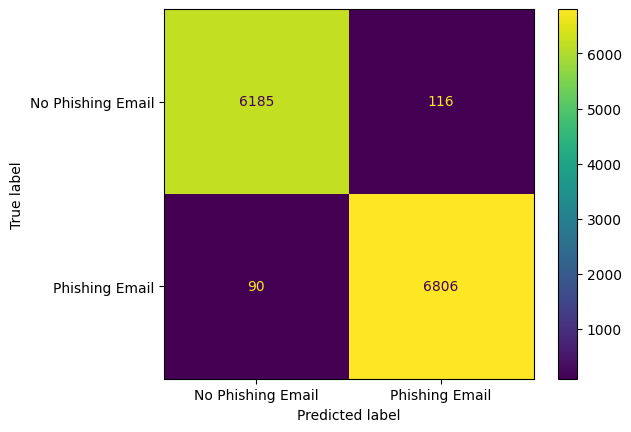


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 2ms/step - accuracy: 0.9671 - loss: 0.0922 - val_accuracy: 0.9815 - val_loss: 0.0562
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9847 - loss: 0.0457 - val_accuracy: 0.9850 - val_loss: 0.0481
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9894 - loss: 0.0310 - val_accuracy: 0.9849 - val_loss: 0.0517
Epoch 4/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9922 - loss: 0.0234 - val_accuracy: 0.9832 - val_loss: 0.0544
Epoch 5/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9942 - loss: 0.0183 - val_accuracy: 0.9857 - val_loss: 0.0512
Epoch 6/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9952 - loss: 0.0140 - val_accuracy: 0.9858 - val_loss: 0.0563
Epoch 7/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9954 - loss: 0.0142 - val_accuracy: 0.9858 - val_loss: 0.0584
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0481, stopped at epoch 7

Print History


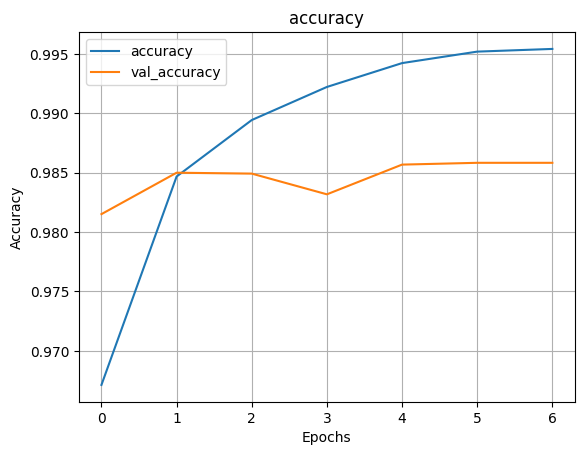

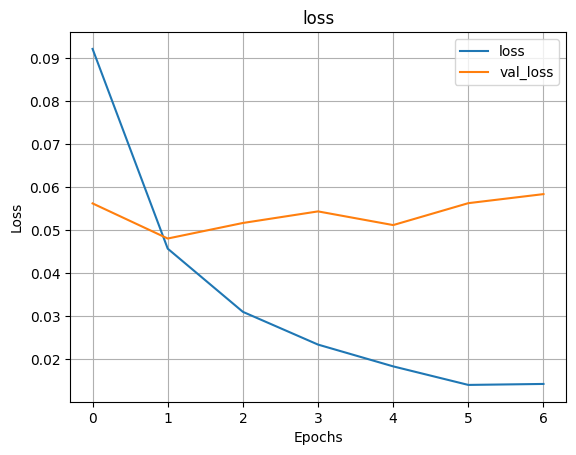

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 575us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



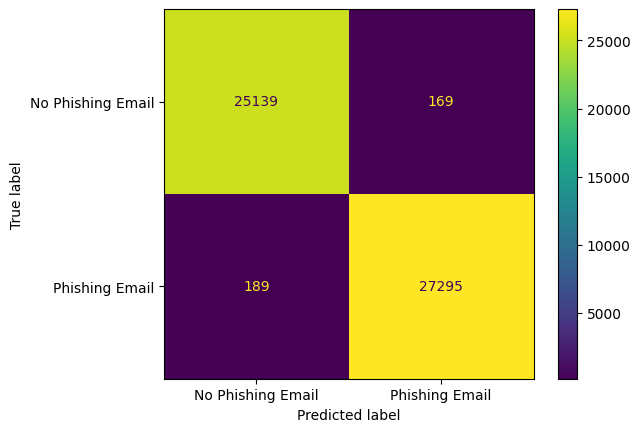

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.99      6896

         accuracy                           0.98     13197
        macro avg       0.99      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



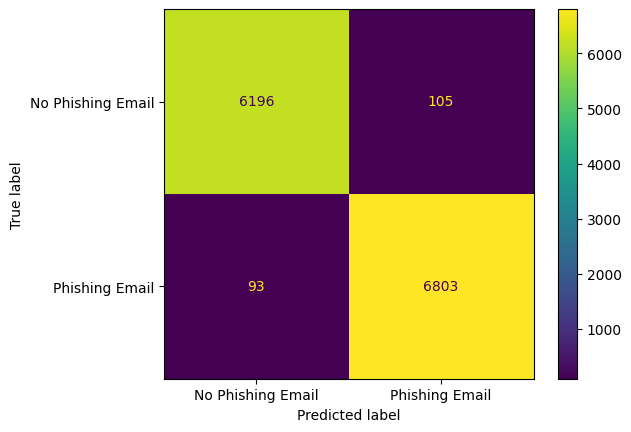


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 2ms/step - accuracy: 0.9673 - loss: 0.0916 - val_accuracy: 0.9814 - val_loss: 0.0561
Epoch 2/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9844 - loss: 0.0452 - val_accuracy: 0.9813 - val_loss: 0.0706
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.0561, stopped at epoch 2

Print History


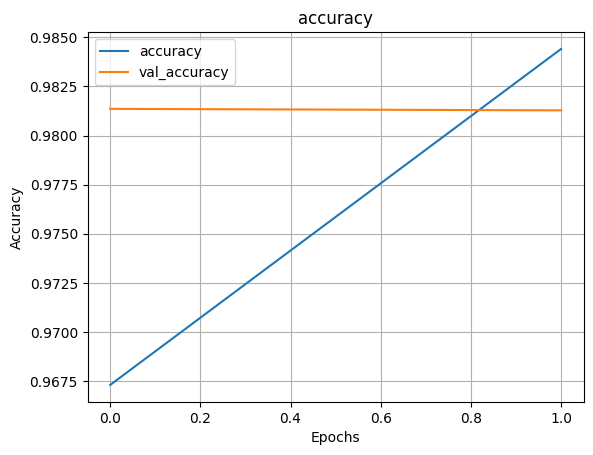

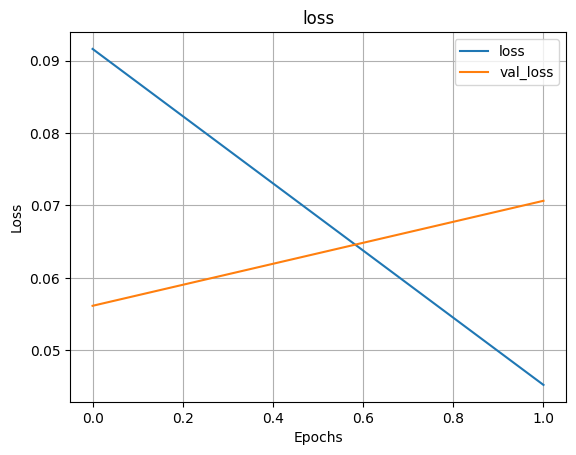

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 437us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.99     25308
   Phishing Email       0.98      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



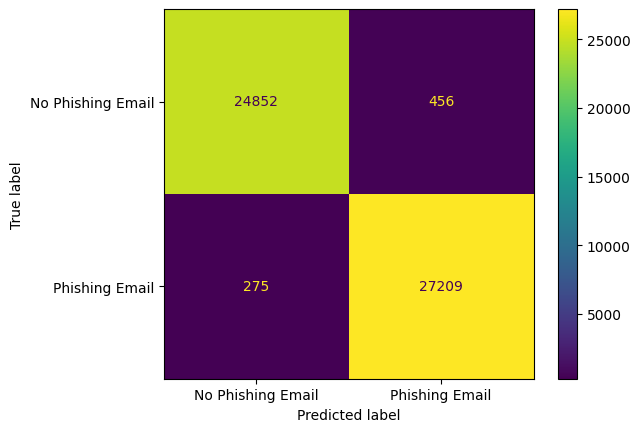

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



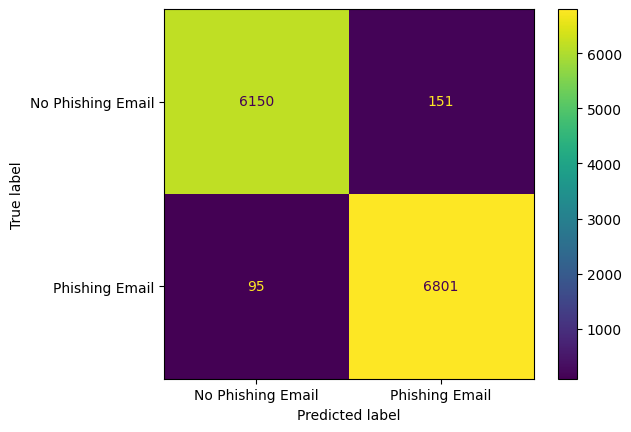


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 3ms/step - accuracy: 0.9683 - loss: 0.0895 - val_accuracy: 0.9811 - val_loss: 0.0585
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9848 - loss: 0.0440 - val_accuracy: 0.9819 - val_loss: 0.0540
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9897 - loss: 0.0306 - val_accuracy: 0.9827 - val_loss: 0.0661
Epoch 4/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9916 - loss: 0.0240 - val_accuracy: 0.9840 - val_loss: 0.0526
Epoch 5/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9938 - loss: 0.0189 - val_accuracy: 0.9844 - val_loss: 0.0594
Epoch 6/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9952 - loss: 0.0138 - val_accuracy: 0.9845 - val_loss: 0.0622
Epoch 7/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9965 - loss: 0.0109 - val_accuracy: 0.9845 - val_loss: 0.0683
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Finished. Best val_loss=0.0526, stopped at epoch 7

Print History


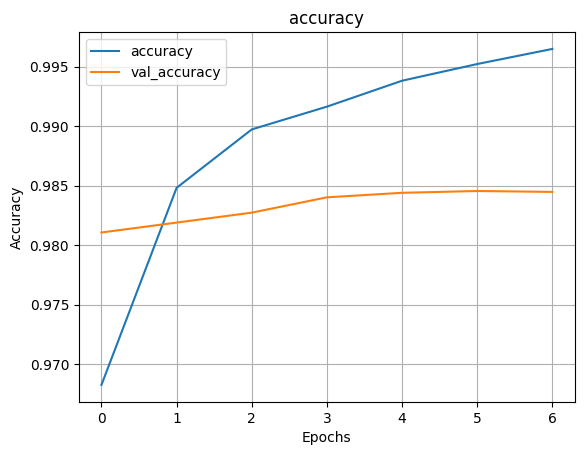

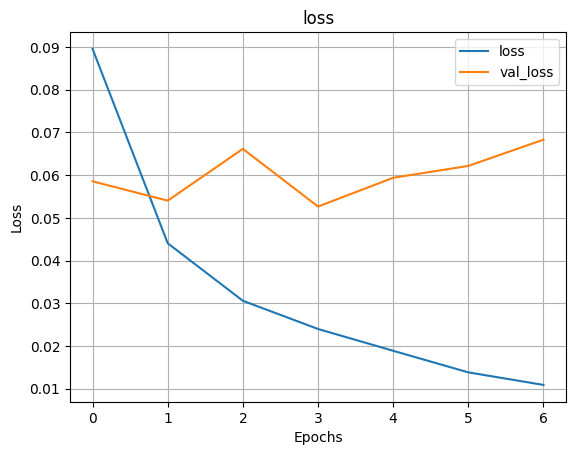

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 424us/step
                   precision    recall  f1-score   support

No Phishing Email       1.00      0.99      1.00     25308
   Phishing Email       0.99      1.00      1.00     27484

         accuracy                           1.00     52792
        macro avg       1.00      1.00      1.00     52792
     weighted avg       1.00      1.00      1.00     52792



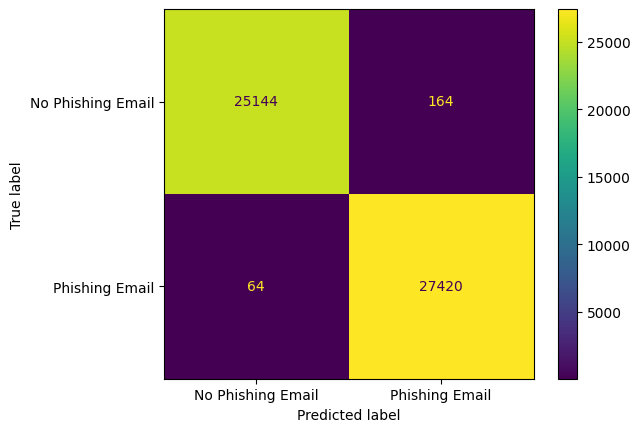

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



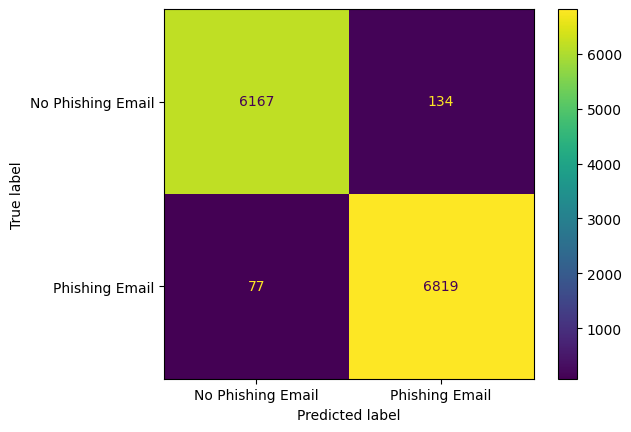


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9665 - loss: 0.0943 - val_accuracy: 0.9814 - val_loss: 0.0552
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9843 - loss: 0.0445 - val_accuracy: 0.9845 - val_loss: 0.0495
Epoch 3/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9886 - loss: 0.0342 - val_accuracy: 0.9797 - val_loss: 0.0805
Epoch 4/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9920 - loss: 0.0231 - val_accuracy: 0.9829 - val_loss: 0.0620
Epoch 5/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9937 - loss: 0.0184 - val_accuracy: 0.9828 - val_loss: 0.0609
Epoch 6/50
1650/1650 - 2s - 998us/step - accuracy: 0.9956 - loss: 0.0161 - val_accuracy: 0.9858 - val_loss: 0.0604
Epoch 7/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9966 - loss: 0.0111 - val_accuracy: 0.9848 - val_loss: 0.0692
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0495, stopped at epoch 7

Print History


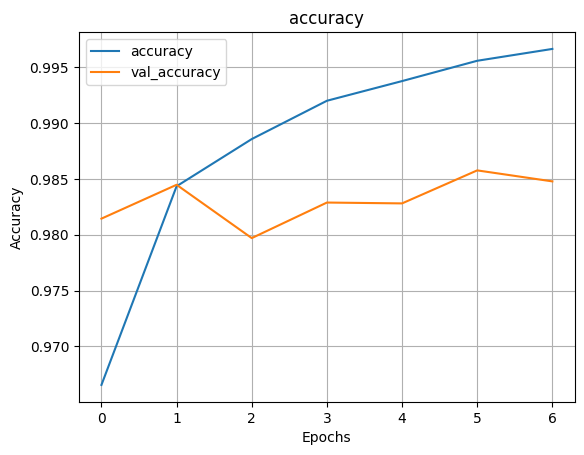

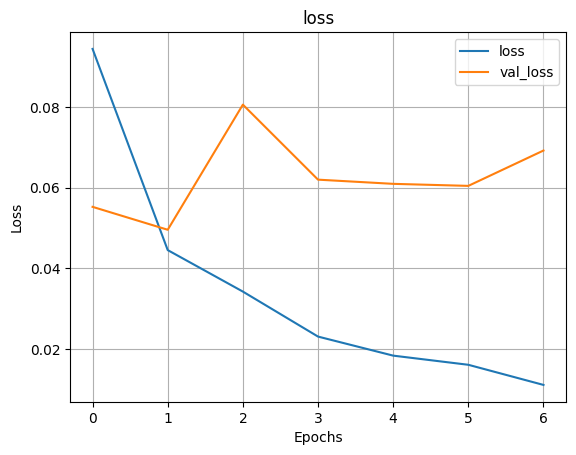

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 505us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



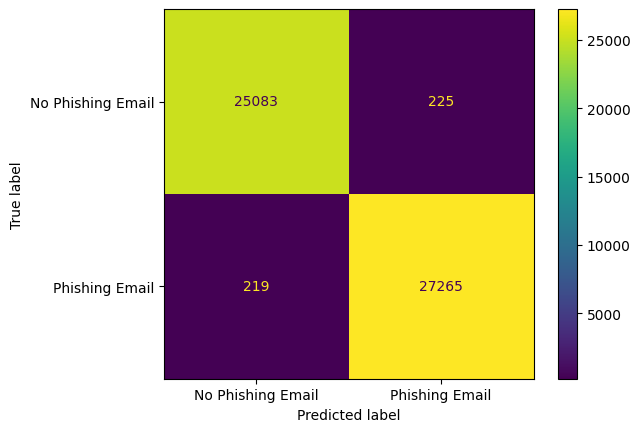

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.99      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



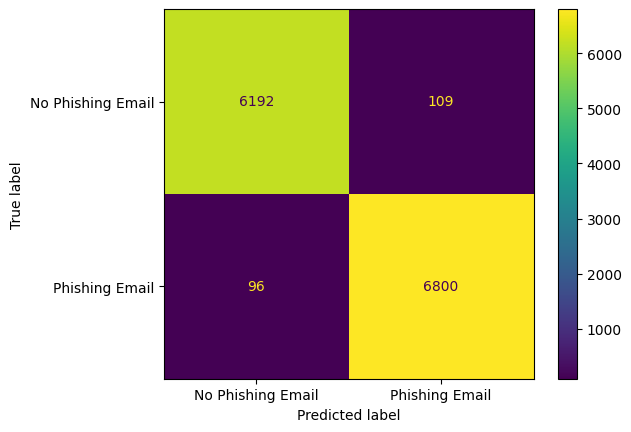


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 3s - 2ms/step - accuracy: 0.9688 - loss: 0.0918 - val_accuracy: 0.9775 - val_loss: 0.0712
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9848 - loss: 0.0461 - val_accuracy: 0.9836 - val_loss: 0.0488
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9894 - loss: 0.0329 - val_accuracy: 0.9835 - val_loss: 0.0489
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0488, stopped at epoch 3

Print History


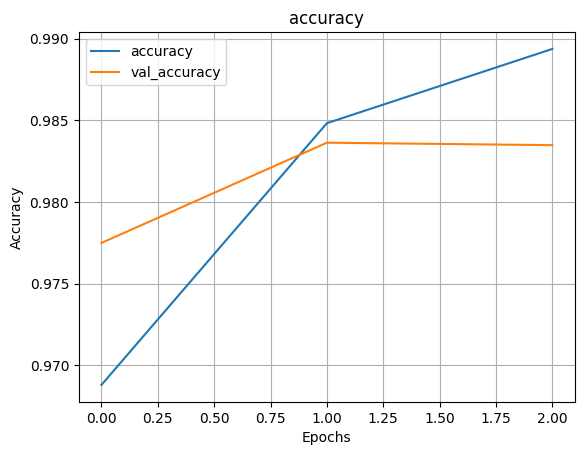

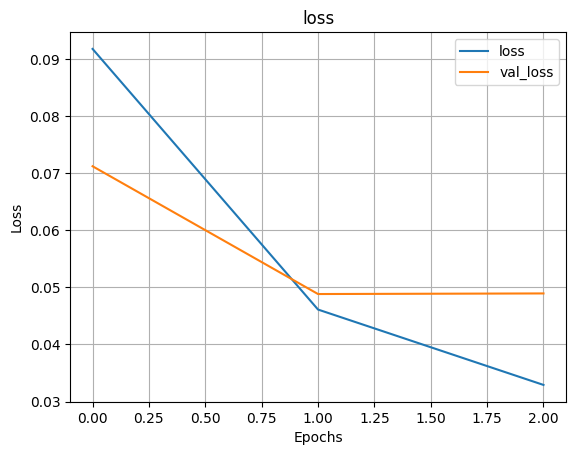

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 538us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



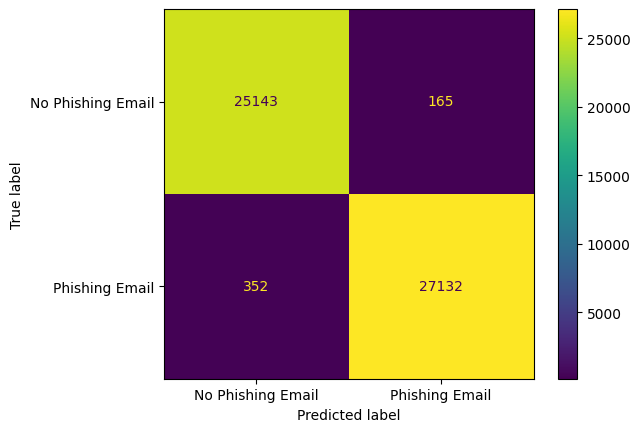

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.99      0.98      6301
   Phishing Email       0.99      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



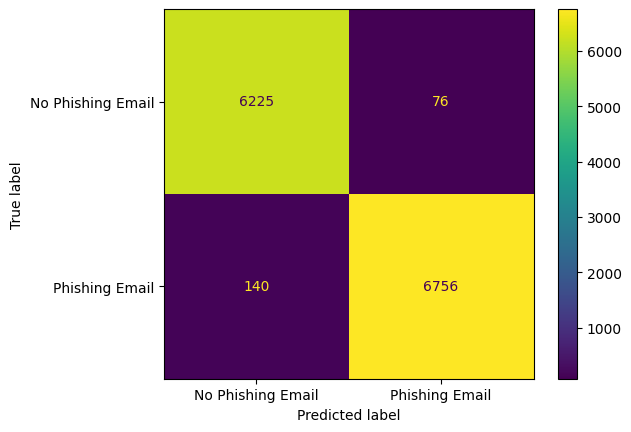


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 2ms/step - accuracy: 0.9686 - loss: 0.0902 - val_accuracy: 0.9778 - val_loss: 0.0733
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9845 - loss: 0.0465 - val_accuracy: 0.9826 - val_loss: 0.0521
Epoch 3/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9886 - loss: 0.0335 - val_accuracy: 0.9842 - val_loss: 0.0466
Epoch 4/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9915 - loss: 0.0239 - val_accuracy: 0.9849 - val_loss: 0.0520
Epoch 5/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9936 - loss: 0.0178 - val_accuracy: 0.9855 - val_loss: 0.0555
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9860 - val_loss: 0.0562
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.0466, stopped at epoch 6

Print History


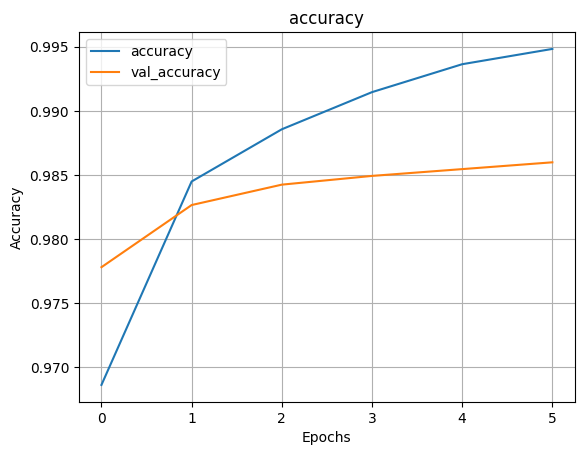

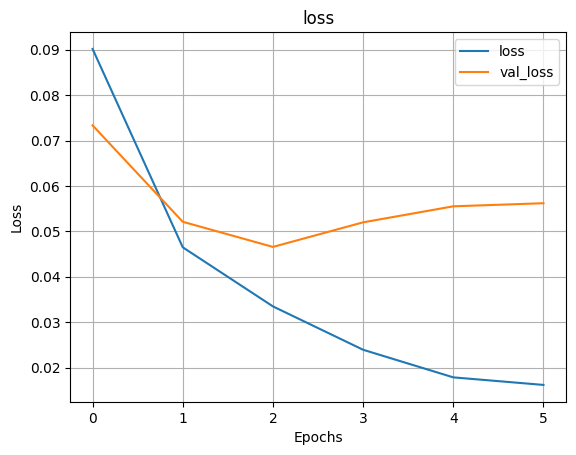

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



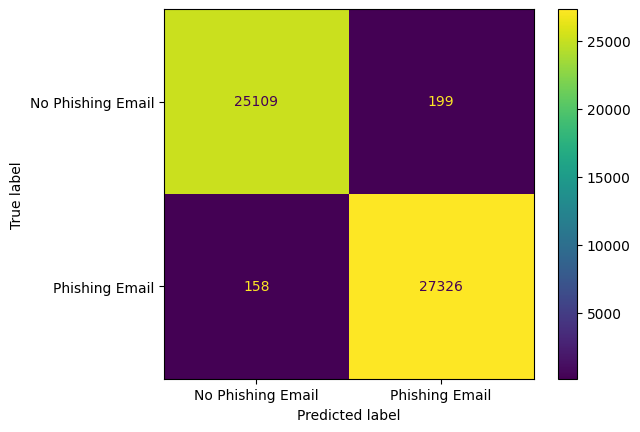

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



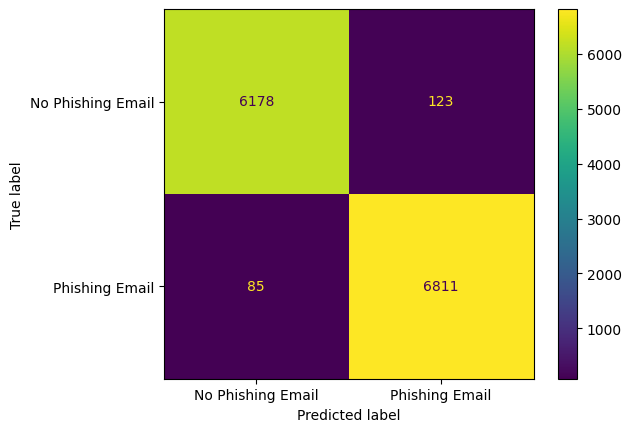


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 2ms/step - accuracy: 0.9668 - loss: 0.0934 - val_accuracy: 0.9794 - val_loss: 0.0588
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9843 - loss: 0.0459 - val_accuracy: 0.9808 - val_loss: 0.0559
Epoch 3/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9891 - loss: 0.0317 - val_accuracy: 0.9848 - val_loss: 0.0487
Epoch 4/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9920 - loss: 0.0226 - val_accuracy: 0.9843 - val_loss: 0.0557
Epoch 5/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9943 - loss: 0.0183 - val_accuracy: 0.9872 - val_loss: 0.0467
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9960 - loss: 0.0130 - val_accuracy: 0.9848 - val_loss: 0.0720
Epoch 7/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9957 - loss: 0.0137 - val_accuracy: 0.9855 - val_loss: 0.0609
Epoch 8/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9972 - loss: 0.0101 - val_accuracy: 0.9870 - val_loss: 0.0550
Epoch 9/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9977 - loss: 0.0071 - val_accuracy: 0.9861 - val

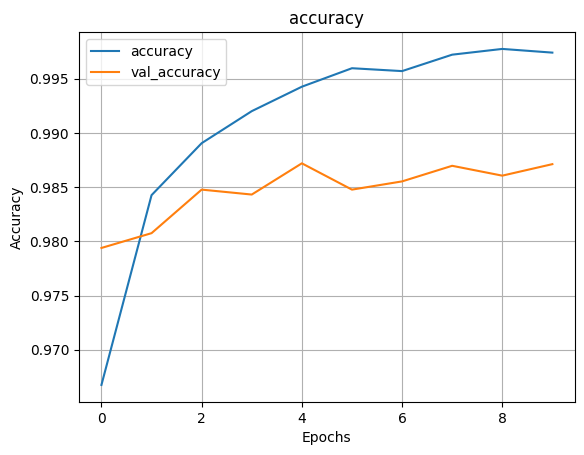

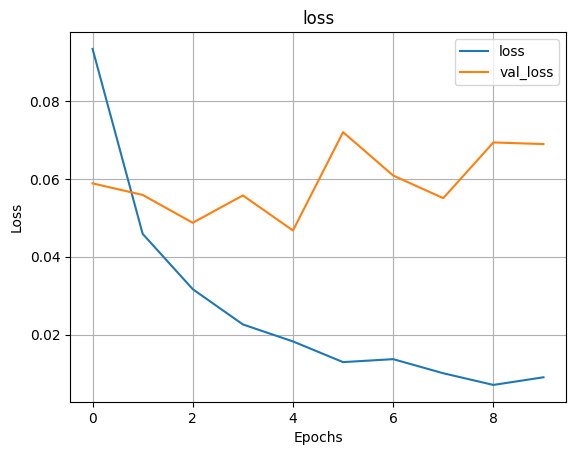

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 803us/step
                   precision    recall  f1-score   support

No Phishing Email       1.00      1.00      1.00     25308
   Phishing Email       1.00      1.00      1.00     27484

         accuracy                           1.00     52792
        macro avg       1.00      1.00      1.00     52792
     weighted avg       1.00      1.00      1.00     52792



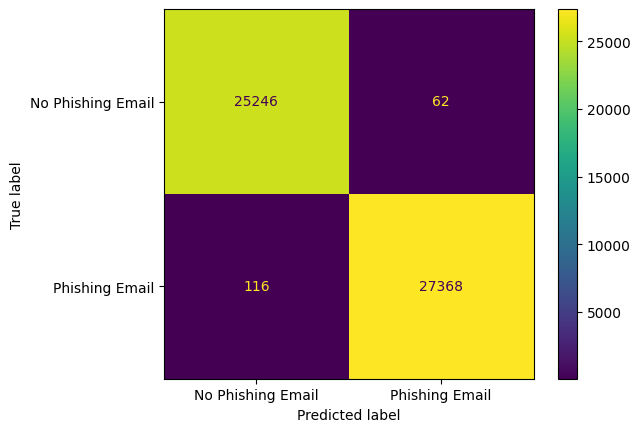

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



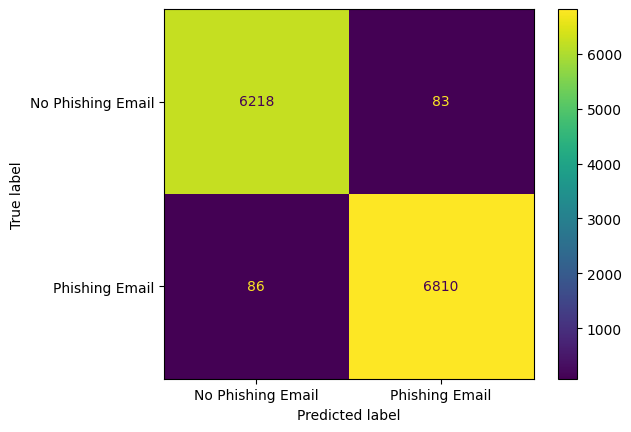


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 2ms/step - accuracy: 0.9684 - loss: 0.0894 - val_accuracy: 0.9793 - val_loss: 0.0627
Epoch 2/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9849 - loss: 0.0437 - val_accuracy: 0.9836 - val_loss: 0.0532
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9894 - loss: 0.0324 - val_accuracy: 0.9817 - val_loss: 0.0563
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0532, stopped at epoch 3

Print History


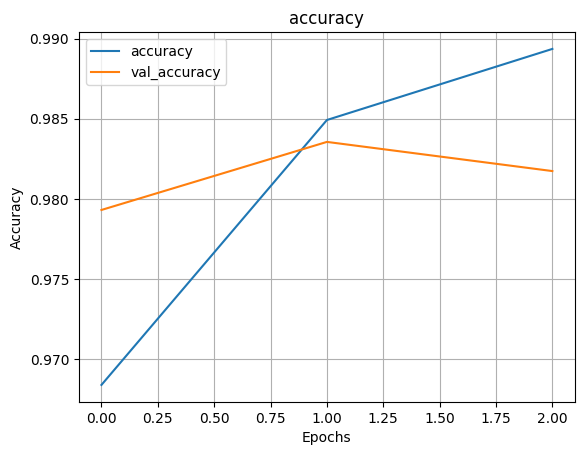

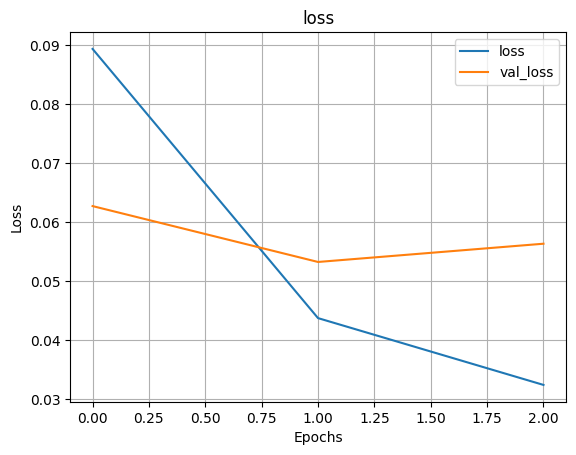

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



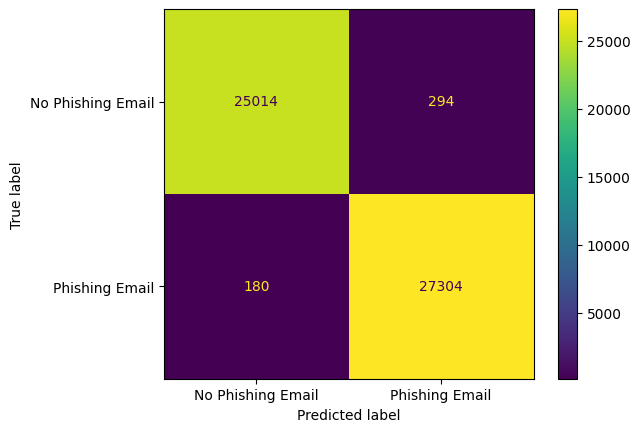

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



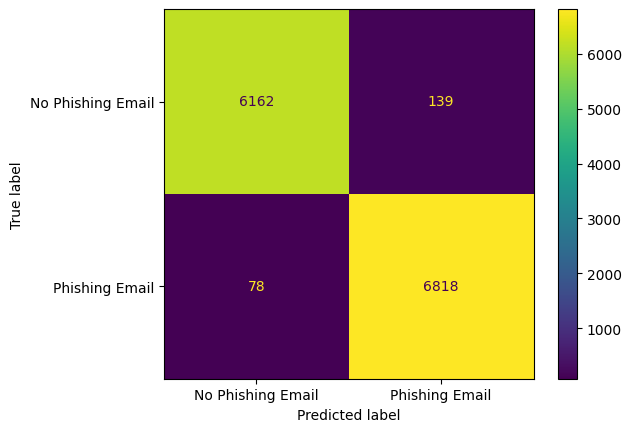


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 3ms/step - accuracy: 0.9679 - loss: 0.0924 - val_accuracy: 0.9783 - val_loss: 0.0660
Epoch 2/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9849 - loss: 0.0450 - val_accuracy: 0.9816 - val_loss: 0.0886
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9883 - loss: 0.0330 - val_accuracy: 0.9835 - val_loss: 0.0513
Epoch 4/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9919 - loss: 0.0249 - val_accuracy: 0.9831 - val_loss: 0.0950
Epoch 5/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9931 - loss: 0.0213 - val_accuracy: 0.9870 - val_loss: 0.0494
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9953 - loss: 0.0156 - val_accuracy: 0.9858 - val_loss: 0.0534
Epoch 7/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9963 - loss: 0.0112 - val_accuracy: 0.9841 - val_loss: 0.0652
Epoch 8/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9965 - loss: 0.0120 - val_accuracy: 0.9837 - val_loss: 0.0642
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 5.
Finished. Best va

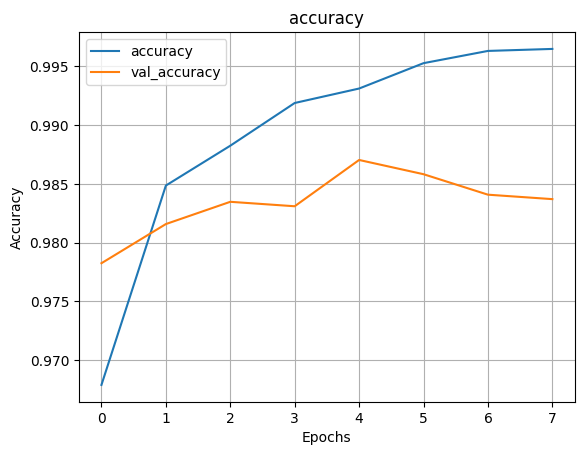

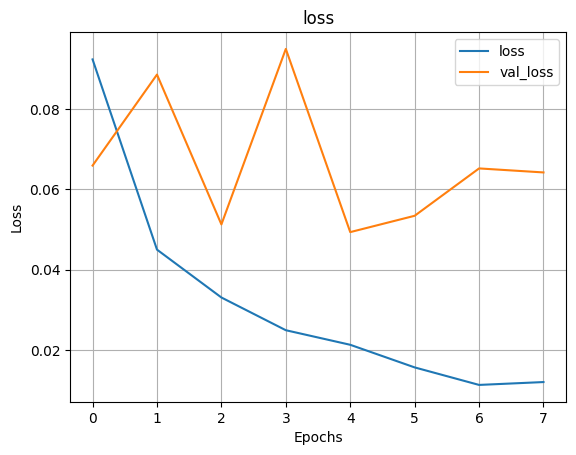

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step
                   precision    recall  f1-score   support

No Phishing Email       1.00      1.00      1.00     25308
   Phishing Email       1.00      1.00      1.00     27484

         accuracy                           1.00     52792
        macro avg       1.00      1.00      1.00     52792
     weighted avg       1.00      1.00      1.00     52792



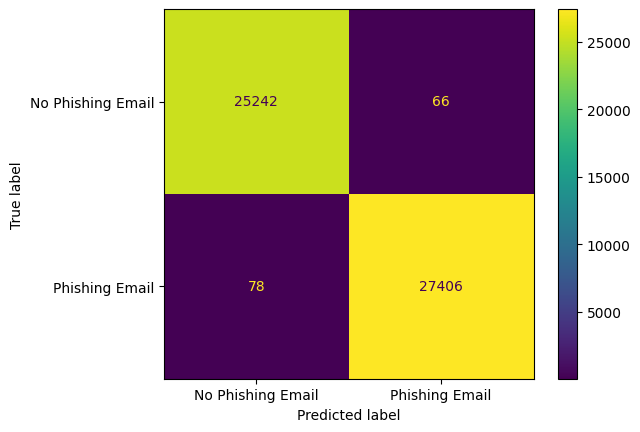

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



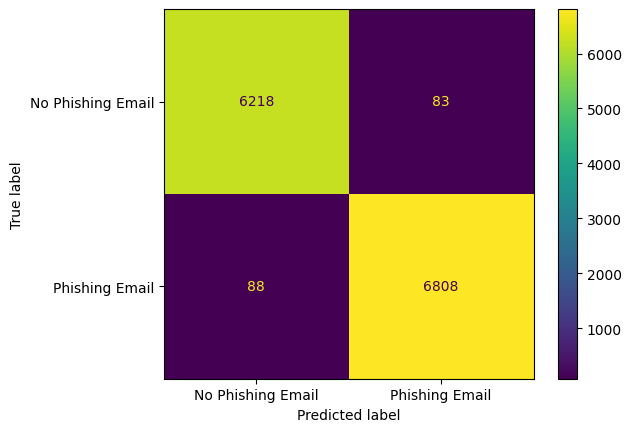


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 2ms/step - accuracy: 0.9676 - loss: 0.0925 - val_accuracy: 0.9816 - val_loss: 0.0554
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9843 - loss: 0.0470 - val_accuracy: 0.9830 - val_loss: 0.0529
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9890 - loss: 0.0330 - val_accuracy: 0.9783 - val_loss: 0.0733
Epoch 4/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9918 - loss: 0.0248 - val_accuracy: 0.9863 - val_loss: 0.0499
Epoch 5/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9944 - loss: 0.0175 - val_accuracy: 0.9836 - val_loss: 0.0558
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9950 - loss: 0.0145 - val_accuracy: 0.9843 - val_loss: 0.0684
Epoch 7/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 0.9830 - val_loss: 0.0694
Epoch 8/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9972 - loss: 0.0088 - val_accuracy: 0.9848 - val_loss: 0.0747
Epoch 9/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9972 - loss: 0.0090 - val_accuracy: 0.9870 - val

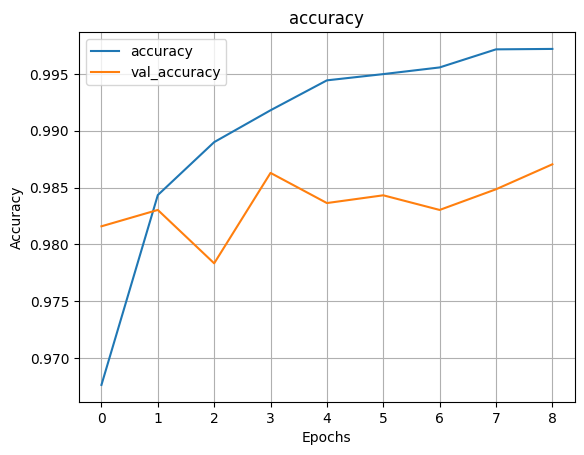

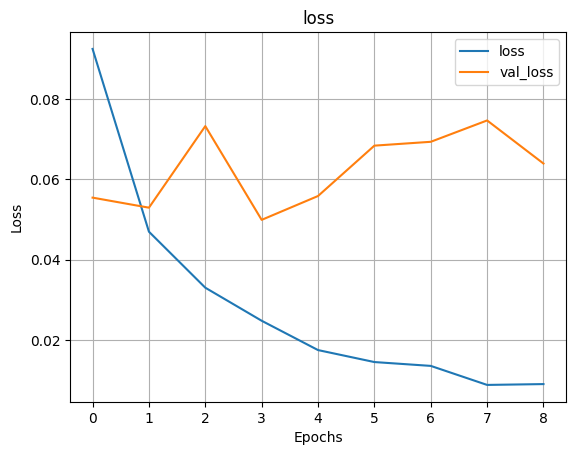

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 603us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      1.00      1.00     25308
   Phishing Email       1.00      0.99      1.00     27484

         accuracy                           1.00     52792
        macro avg       1.00      1.00      1.00     52792
     weighted avg       1.00      1.00      1.00     52792



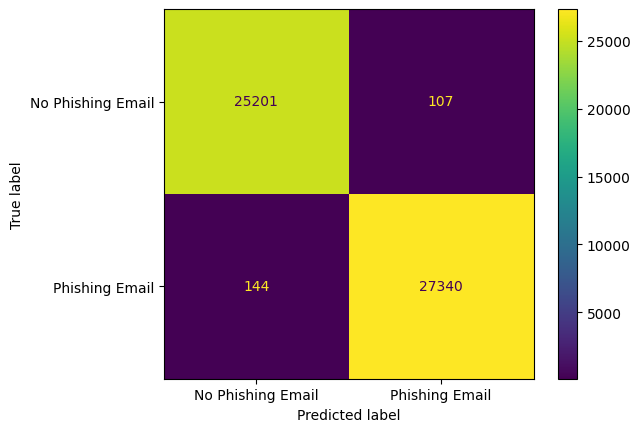

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.99      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



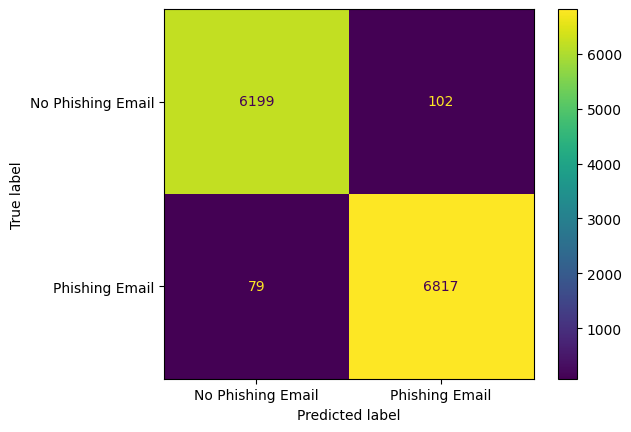


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 7s - 4ms/step - accuracy: 0.9714 - loss: 0.0827 - val_accuracy: 0.9824 - val_loss: 0.0524
Epoch 2/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9851 - loss: 0.0424 - val_accuracy: 0.9838 - val_loss: 0.0527
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.0524, stopped at epoch 2

Print History


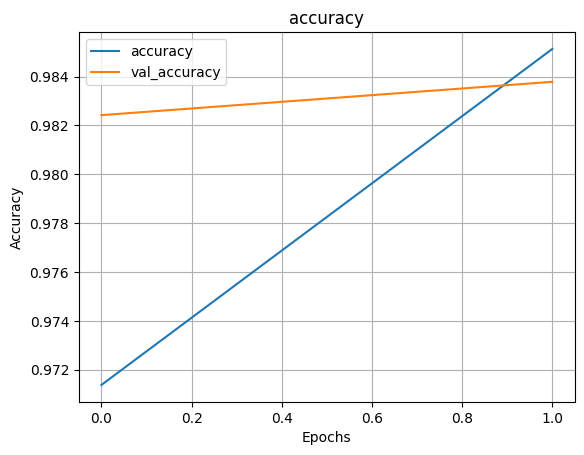

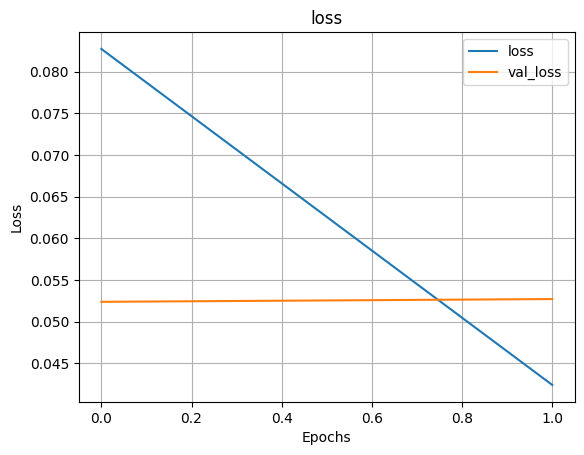

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



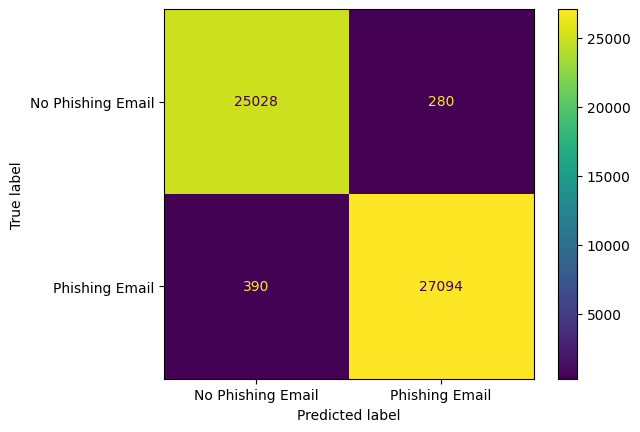

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



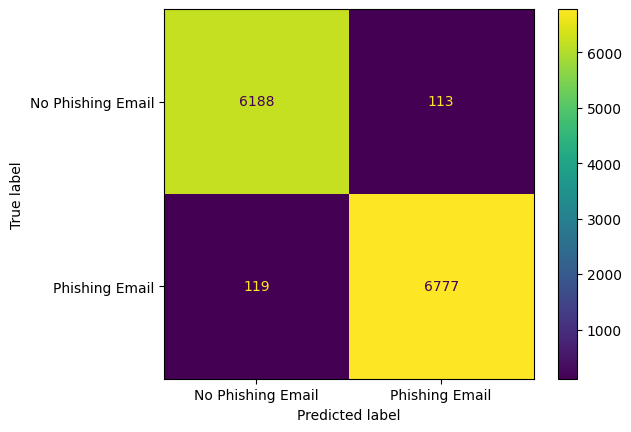


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 5s - 3ms/step - accuracy: 0.9694 - loss: 0.0856 - val_accuracy: 0.9802 - val_loss: 0.0570
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9849 - loss: 0.0433 - val_accuracy: 0.9839 - val_loss: 0.0481
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9897 - loss: 0.0311 - val_accuracy: 0.9848 - val_loss: 0.0519
Epoch 4/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9915 - loss: 0.0236 - val_accuracy: 0.9860 - val_loss: 0.0461
Epoch 5/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9928 - loss: 0.0201 - val_accuracy: 0.9861 - val_loss: 0.0474
Epoch 6/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9947 - loss: 0.0159 - val_accuracy: 0.9855 - val_loss: 0.0520
Epoch 7/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9954 - loss: 0.0140 - val_accuracy: 0.9871 - val_loss: 0.0572
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Finished. Best val_loss=0.0461, stopped at epoch 7

Print History


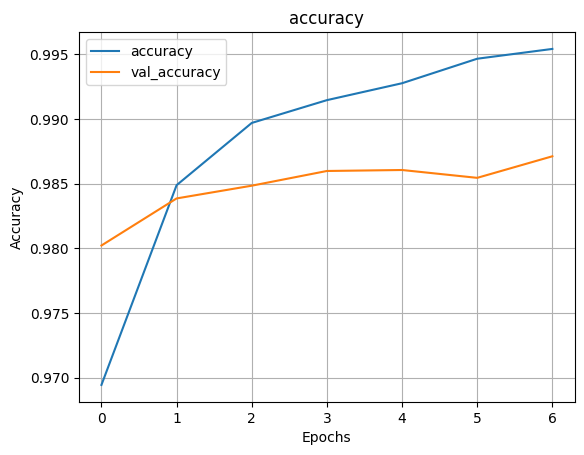

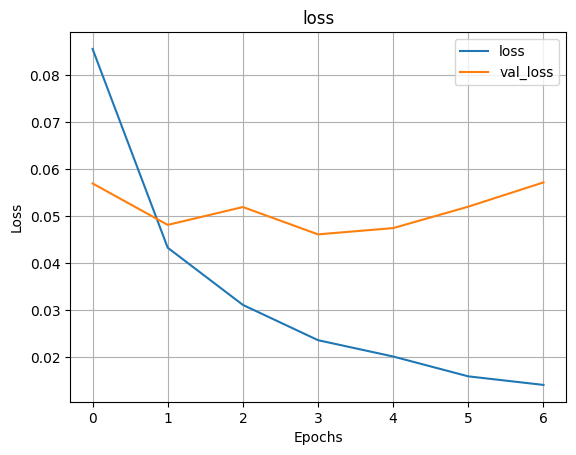

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       1.00      0.99      1.00     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



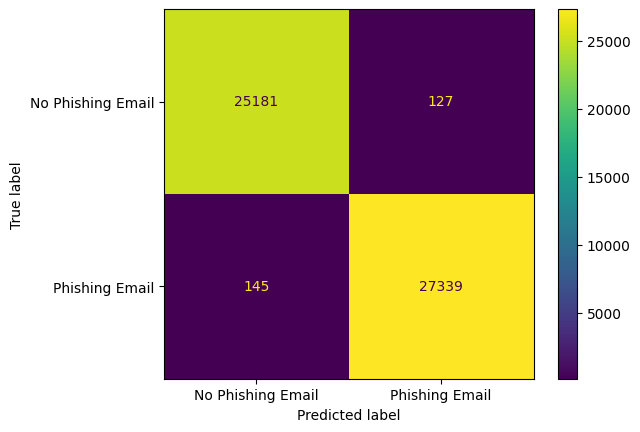

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.99      0.99      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



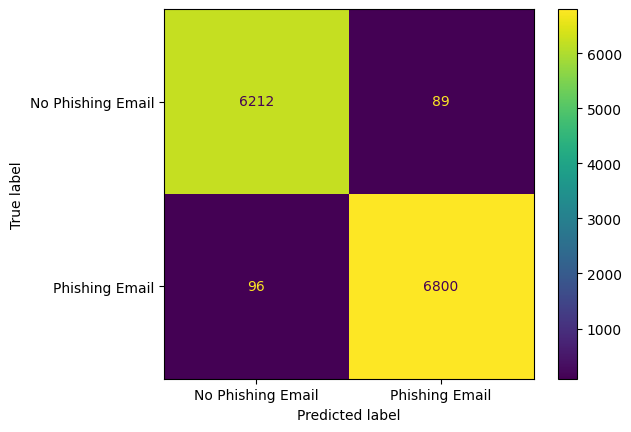


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 3ms/step - accuracy: 0.9712 - loss: 0.0817 - val_accuracy: 0.9808 - val_loss: 0.0521
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9846 - loss: 0.0435 - val_accuracy: 0.9829 - val_loss: 0.0484
Epoch 3/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9887 - loss: 0.0312 - val_accuracy: 0.9853 - val_loss: 0.0445
Epoch 4/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9919 - loss: 0.0237 - val_accuracy: 0.9870 - val_loss: 0.0487
Epoch 5/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9935 - loss: 0.0192 - val_accuracy: 0.9856 - val_loss: 0.0487
Epoch 6/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9944 - loss: 0.0164 - val_accuracy: 0.9873 - val_loss: 0.0493
Epoch 7/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9958 - loss: 0.0132 - val_accuracy: 0.9864 - val_loss: 0.0580
Epoch 8/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9961 - loss: 0.0121 - val_accuracy: 0.9869 - val_loss: 0.0569
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=

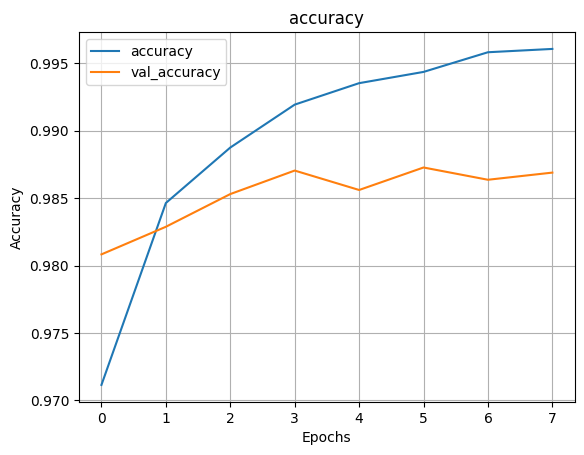

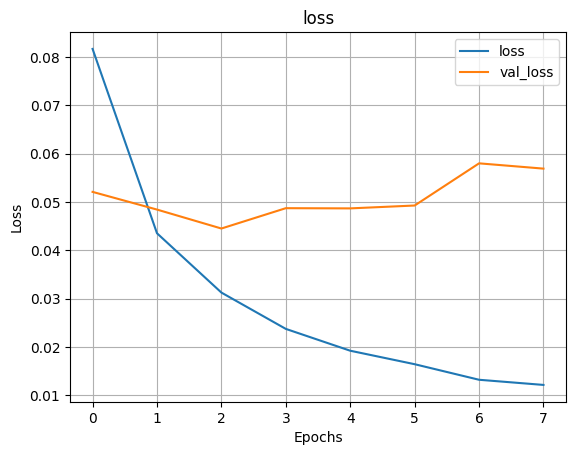

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      1.00      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



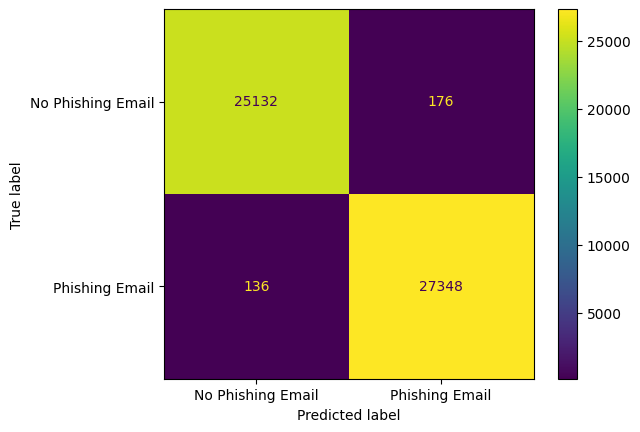

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



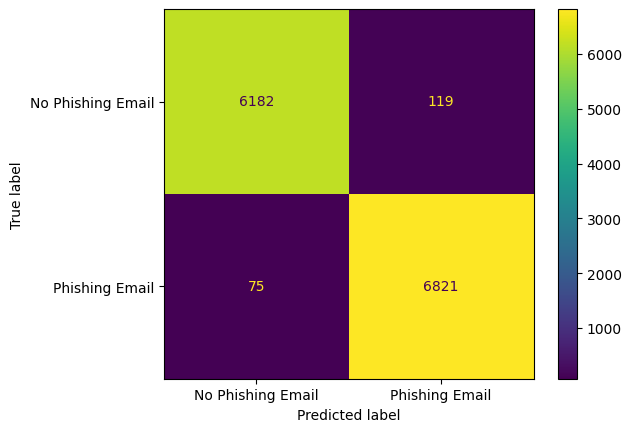


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 5s - 3ms/step - accuracy: 0.9700 - loss: 0.0846 - val_accuracy: 0.9812 - val_loss: 0.0574
Epoch 2/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9842 - loss: 0.0437 - val_accuracy: 0.9823 - val_loss: 0.0545
Epoch 3/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9890 - loss: 0.0308 - val_accuracy: 0.9856 - val_loss: 0.0561
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0545, stopped at epoch 3

Print History


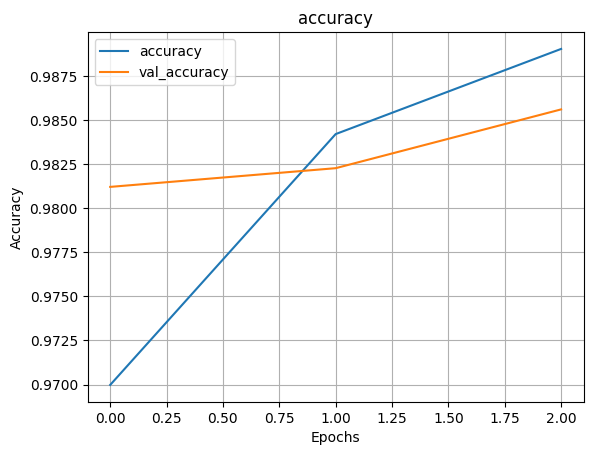

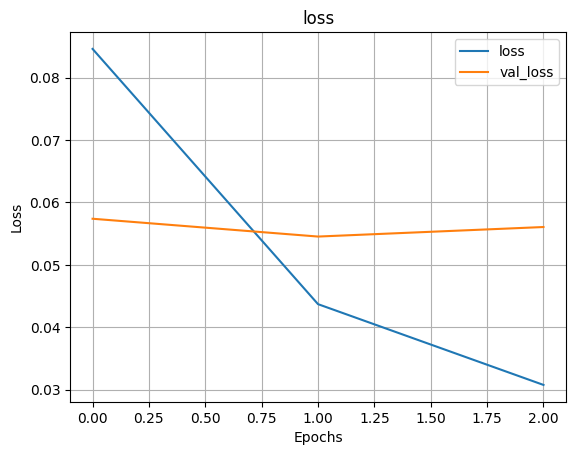

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



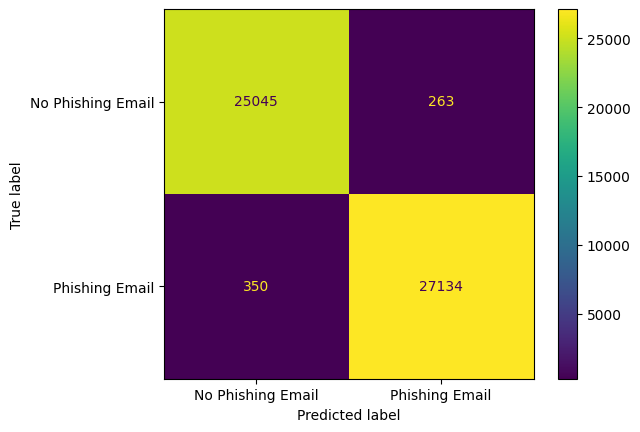

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



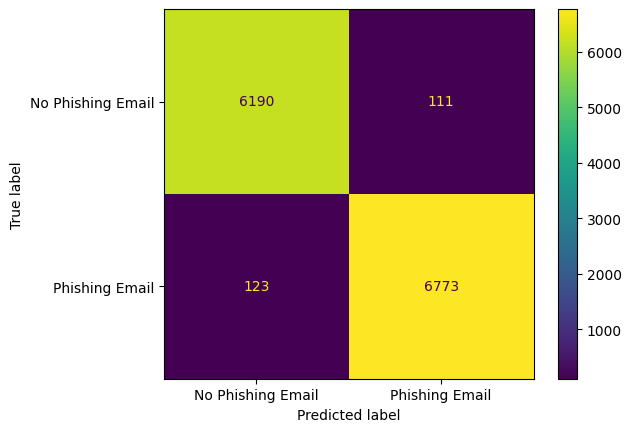


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 3ms/step - accuracy: 0.9703 - loss: 0.0836 - val_accuracy: 0.9822 - val_loss: 0.0523
Epoch 2/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9850 - loss: 0.0420 - val_accuracy: 0.9839 - val_loss: 0.0500
Epoch 3/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9888 - loss: 0.0312 - val_accuracy: 0.9864 - val_loss: 0.0449
Epoch 4/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9919 - loss: 0.0227 - val_accuracy: 0.9860 - val_loss: 0.0536
Epoch 5/50
1650/1650 - 2s - 943us/step - accuracy: 0.9935 - loss: 0.0194 - val_accuracy: 0.9867 - val_loss: 0.0497
Epoch 6/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9944 - loss: 0.0156 - val_accuracy: 0.9848 - val_loss: 0.0596
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.0449, stopped at epoch 6

Print History


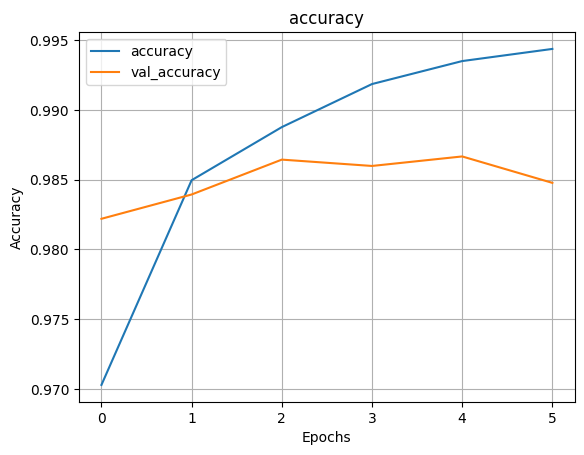

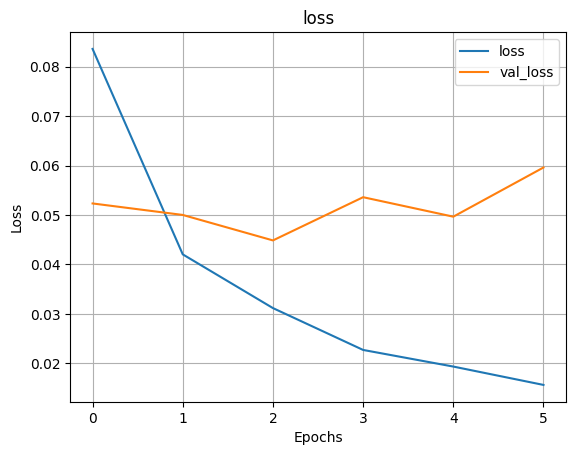

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



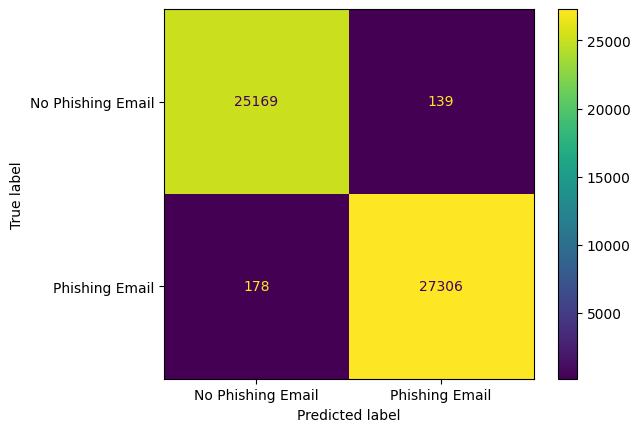

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



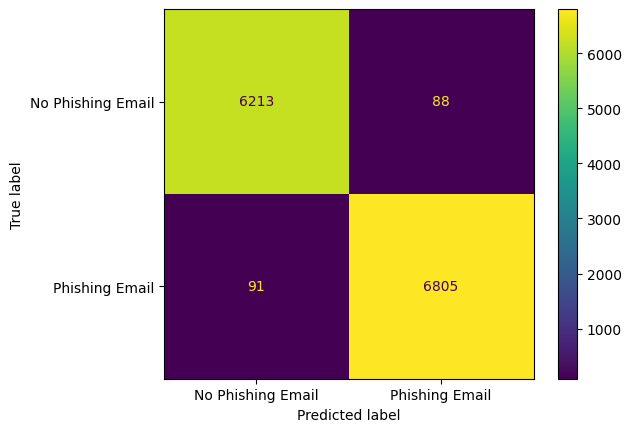


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 2ms/step - accuracy: 0.9697 - loss: 0.0842 - val_accuracy: 0.9801 - val_loss: 0.0557
Epoch 2/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9848 - loss: 0.0427 - val_accuracy: 0.9814 - val_loss: 0.0551
Epoch 3/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9893 - loss: 0.0320 - val_accuracy: 0.9842 - val_loss: 0.0460
Epoch 4/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9918 - loss: 0.0241 - val_accuracy: 0.9858 - val_loss: 0.0467
Epoch 5/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9934 - loss: 0.0197 - val_accuracy: 0.9870 - val_loss: 0.0533
Epoch 6/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9948 - loss: 0.0156 - val_accuracy: 0.9854 - val_loss: 0.0499
Epoch 7/50
1650/1650 - 2s - 1ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.9864 - val_loss: 0.0600
Epoch 8/50
1650/1650 - 3s - 2ms/step - accuracy: 0.9962 - loss: 0.0120 - val_accuracy: 0.9852 - val_loss: 0.0663
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=

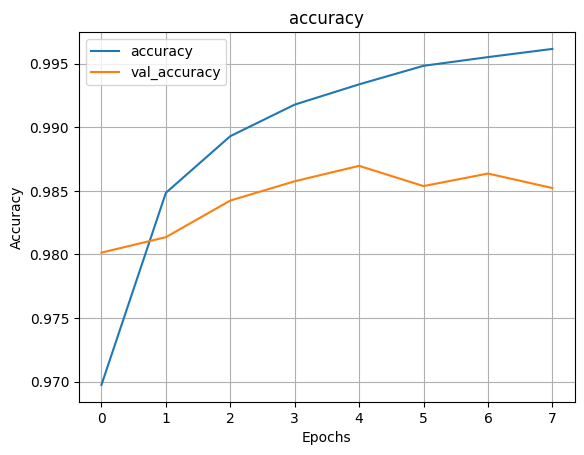

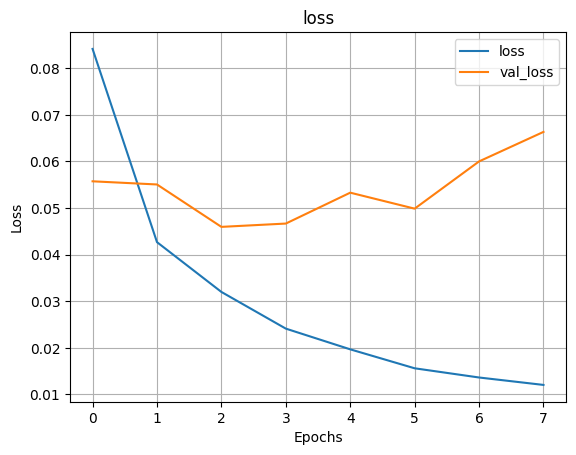

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 581us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       1.00      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



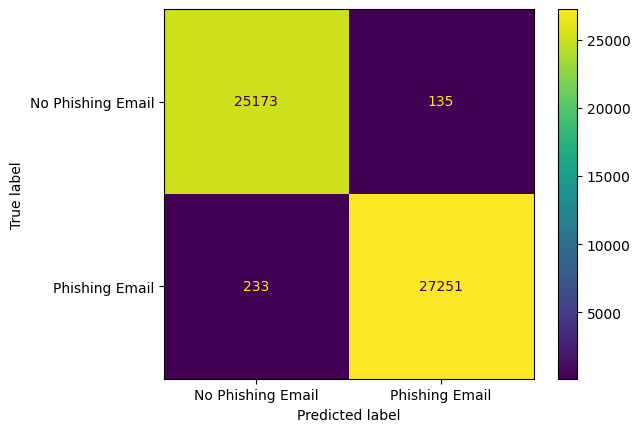

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.99      0.98      6301
   Phishing Email       0.99      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



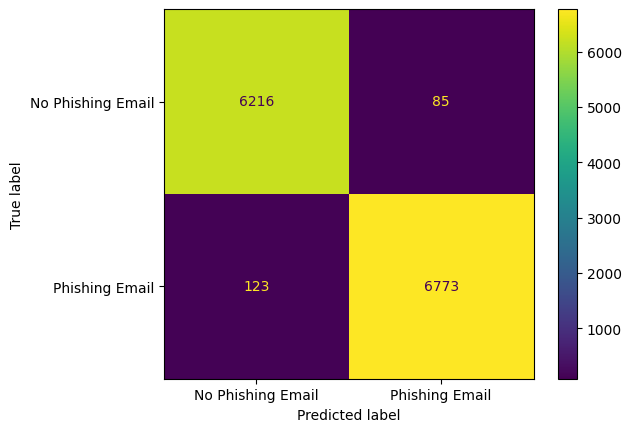


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 3ms/step - accuracy: 0.9704 - loss: 0.0833 - val_accuracy: 0.9817 - val_loss: 0.0524
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9849 - loss: 0.0432 - val_accuracy: 0.9820 - val_loss: 0.0502
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9886 - loss: 0.0321 - val_accuracy: 0.9845 - val_loss: 0.0507
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0502, stopped at epoch 3

Print History


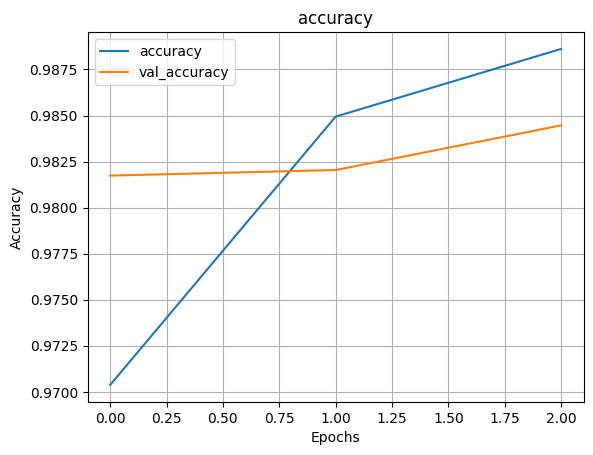

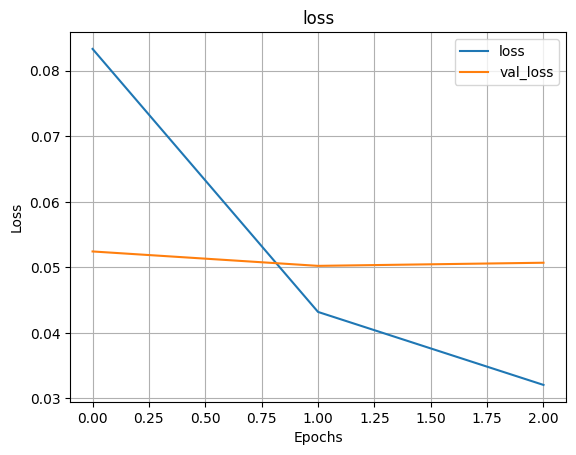

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



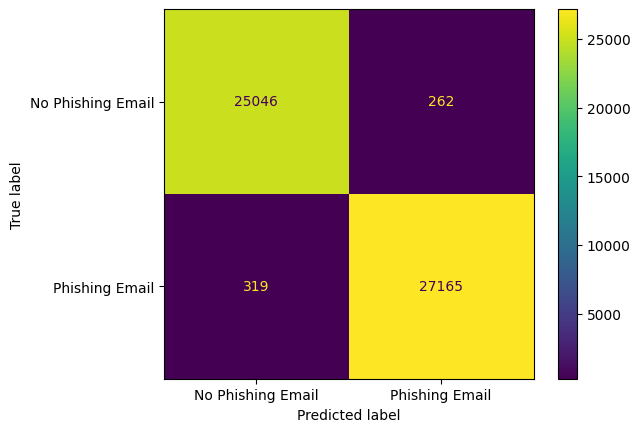

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



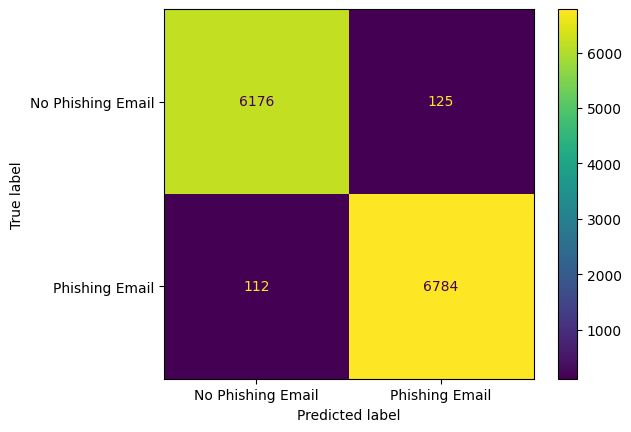


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 5s - 3ms/step - accuracy: 0.9703 - loss: 0.0847 - val_accuracy: 0.9814 - val_loss: 0.0541
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9847 - loss: 0.0424 - val_accuracy: 0.9850 - val_loss: 0.0468
Epoch 3/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9892 - loss: 0.0307 - val_accuracy: 0.9803 - val_loss: 0.0616
Epoch 4/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9911 - loss: 0.0243 - val_accuracy: 0.9858 - val_loss: 0.0460
Epoch 5/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9933 - loss: 0.0191 - val_accuracy: 0.9844 - val_loss: 0.0574
Epoch 6/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9944 - loss: 0.0163 - val_accuracy: 0.9839 - val_loss: 0.0689
Epoch 7/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9955 - loss: 0.0133 - val_accuracy: 0.9867 - val_loss: 0.0528
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Finished. Best val_loss=0.0460, stopped at epoch 7

Print History


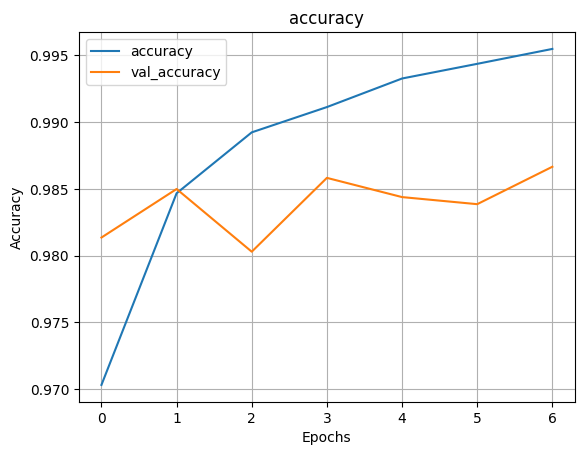

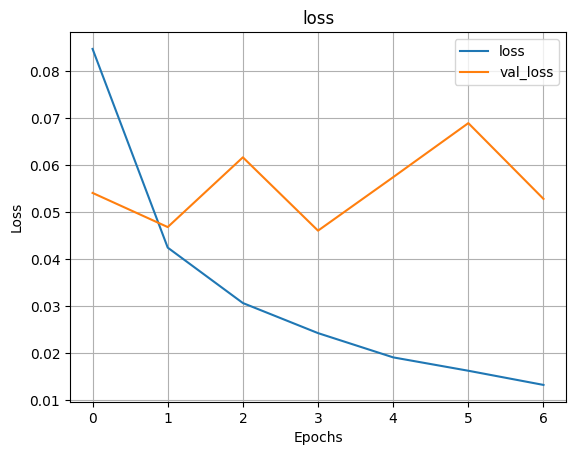

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 2s 776us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      1.00      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



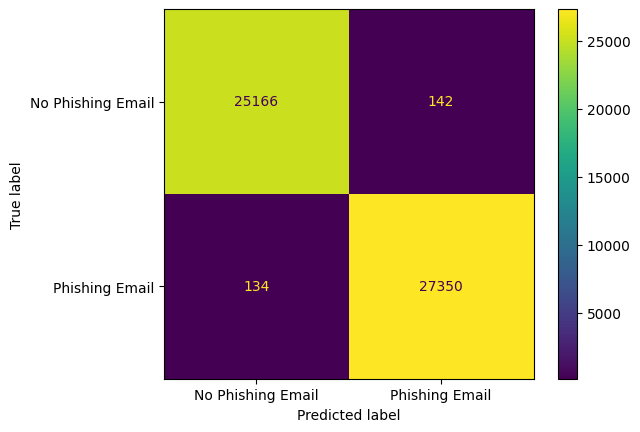

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.99      6301
   Phishing Email       0.98      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



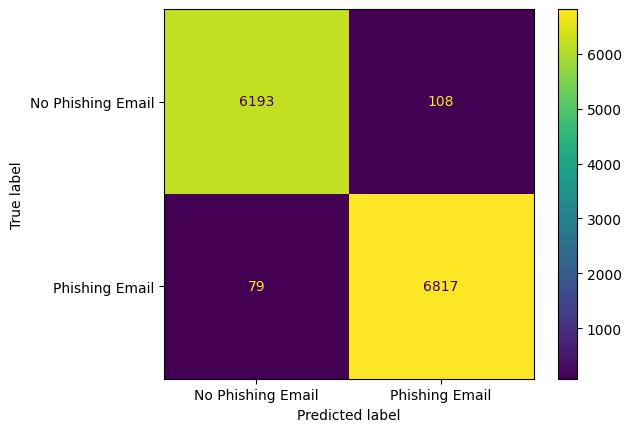


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 5s - 3ms/step - accuracy: 0.9691 - loss: 0.0872 - val_accuracy: 0.9796 - val_loss: 0.0593
Epoch 2/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9854 - loss: 0.0436 - val_accuracy: 0.9833 - val_loss: 0.0501
Epoch 3/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9896 - loss: 0.0312 - val_accuracy: 0.9855 - val_loss: 0.0458
Epoch 4/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9921 - loss: 0.0223 - val_accuracy: 0.9836 - val_loss: 0.0542
Epoch 5/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9928 - loss: 0.0201 - val_accuracy: 0.9858 - val_loss: 0.0471
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9949 - loss: 0.0160 - val_accuracy: 0.9856 - val_loss: 0.0518
Epoch 7/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9957 - loss: 0.0125 - val_accuracy: 0.9873 - val_loss: 0.0664
Epoch 8/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9959 - loss: 0.0125 - val_accuracy: 0.9851 - val_loss: 0.0606
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best va

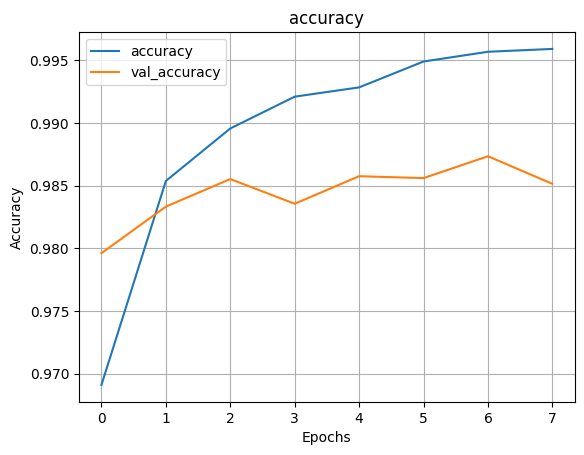

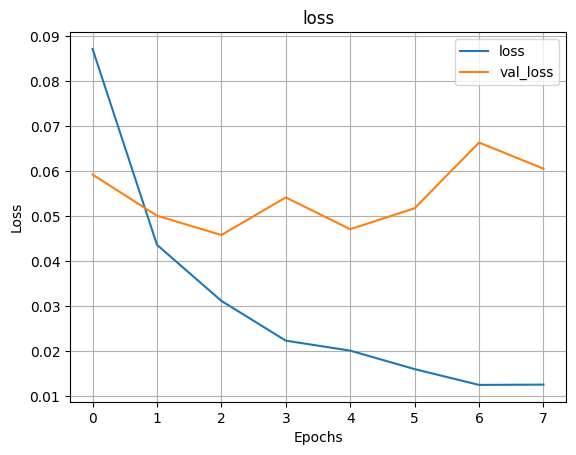

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



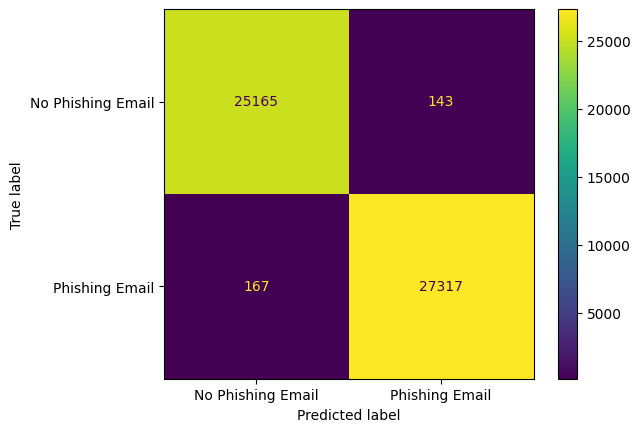

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.99      0.98      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



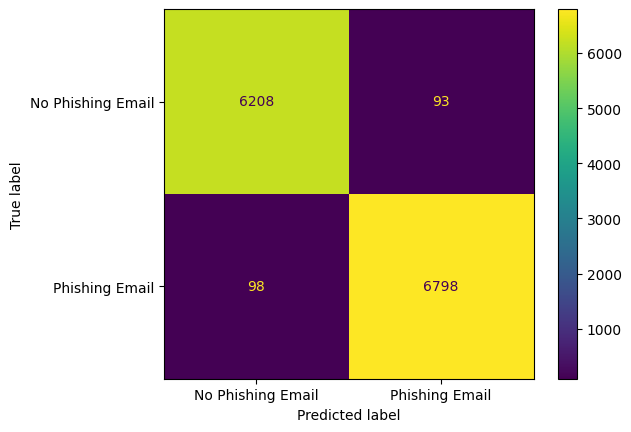


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 5s - 3ms/step - accuracy: 0.9699 - loss: 0.0829 - val_accuracy: 0.9792 - val_loss: 0.0604
Epoch 2/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9852 - loss: 0.0427 - val_accuracy: 0.9828 - val_loss: 0.0492
Epoch 3/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9897 - loss: 0.0306 - val_accuracy: 0.9853 - val_loss: 0.0507
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.0492, stopped at epoch 3

Print History


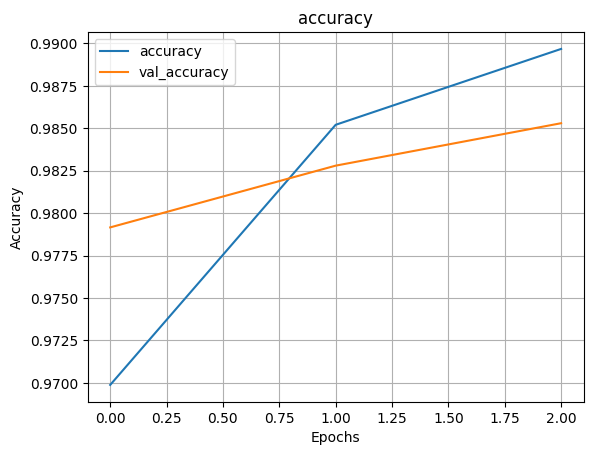

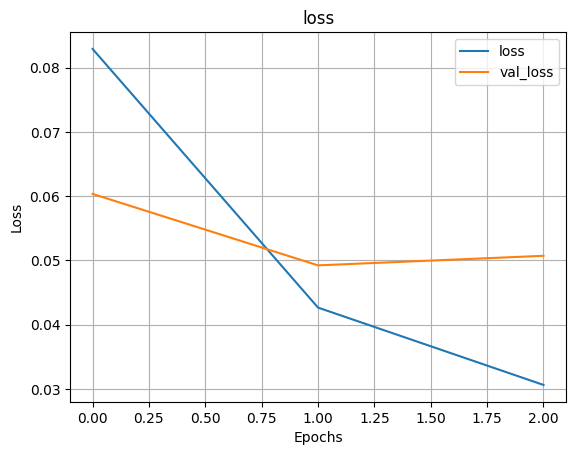

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 2s 793us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



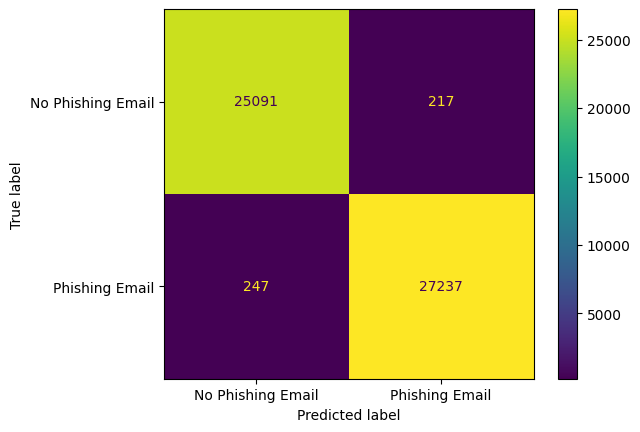

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



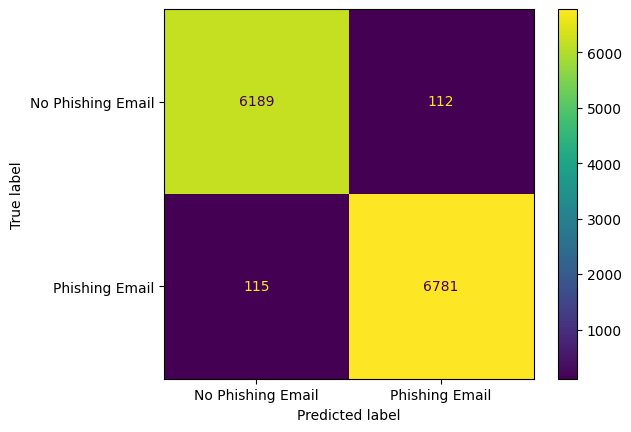


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 5s - 3ms/step - accuracy: 0.9709 - loss: 0.0810 - val_accuracy: 0.9804 - val_loss: 0.0581
Epoch 2/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9850 - loss: 0.0428 - val_accuracy: 0.9835 - val_loss: 0.0539
Epoch 3/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9887 - loss: 0.0317 - val_accuracy: 0.9839 - val_loss: 0.0498
Epoch 4/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9911 - loss: 0.0241 - val_accuracy: 0.9847 - val_loss: 0.0510
Epoch 5/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9936 - loss: 0.0177 - val_accuracy: 0.9872 - val_loss: 0.0527
Epoch 6/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9952 - loss: 0.0146 - val_accuracy: 0.9856 - val_loss: 0.0560
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.0498, stopped at epoch 6

Print History


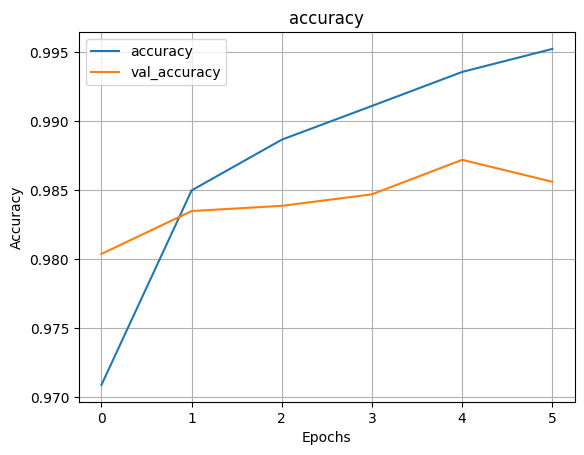

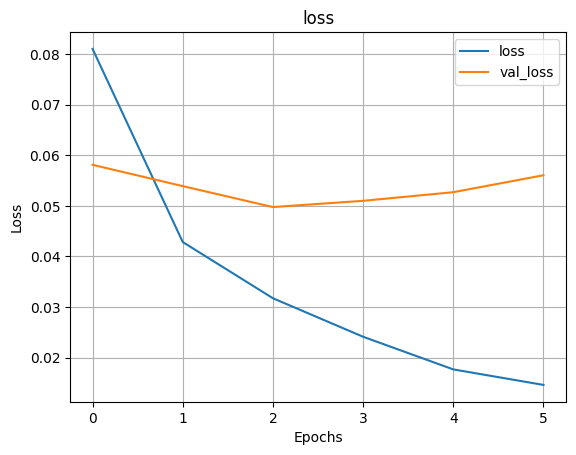

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 2s 938us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



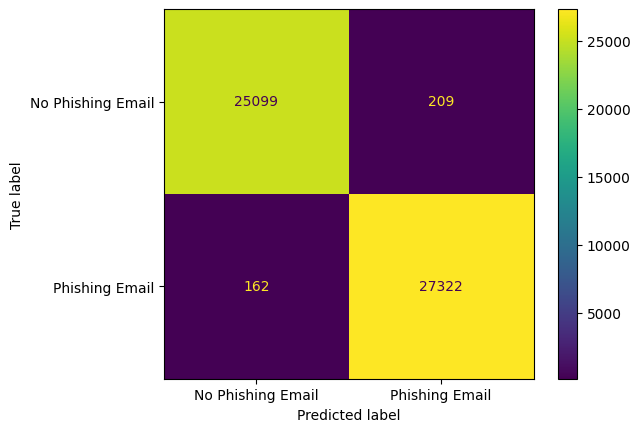

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.98      6301
   Phishing Email       0.98      0.99      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



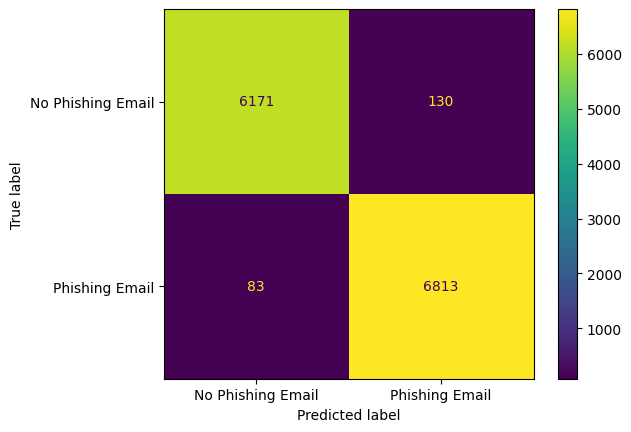


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/home/rod/MyApps/git_repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 4s - 2ms/step - accuracy: 0.9704 - loss: 0.0835 - val_accuracy: 0.9792 - val_loss: 0.0576
Epoch 2/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9854 - loss: 0.0426 - val_accuracy: 0.9831 - val_loss: 0.0482
Epoch 3/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9889 - loss: 0.0316 - val_accuracy: 0.9867 - val_loss: 0.0429
Epoch 4/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9917 - loss: 0.0236 - val_accuracy: 0.9839 - val_loss: 0.0518
Epoch 5/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9933 - loss: 0.0197 - val_accuracy: 0.9858 - val_loss: 0.0518
Epoch 6/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9947 - loss: 0.0149 - val_accuracy: 0.9867 - val_loss: 0.0482
Epoch 7/100
1650/1650 - 3s - 2ms/step - accuracy: 0.9955 - loss: 0.0135 - val_accuracy: 0.9831 - val_loss: 0.0614
Epoch 8/100
1650/1650 - 2s - 1ms/step - accuracy: 0.9961 - loss: 0.0113 - val_accuracy: 0.9862 - val_loss: 0.0586
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best va

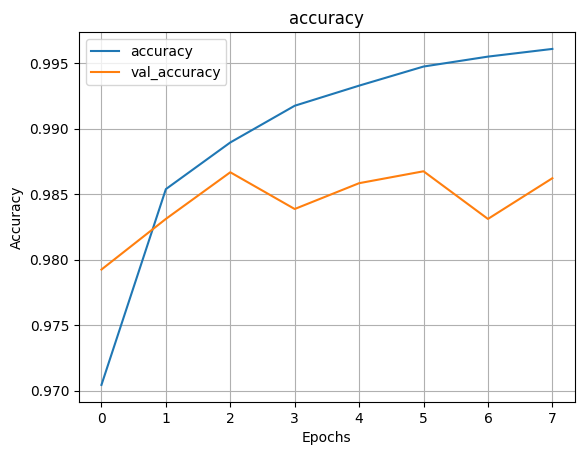

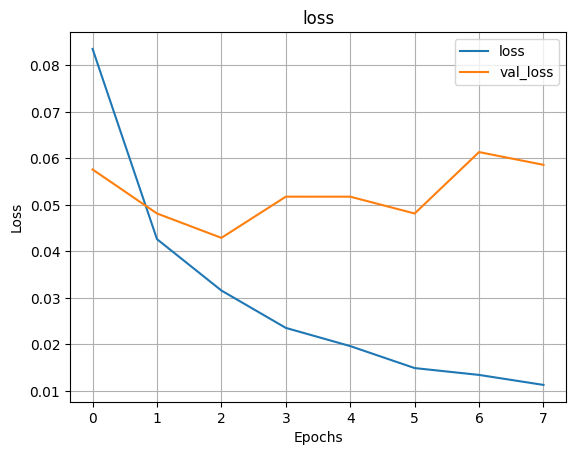

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 701us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.99      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



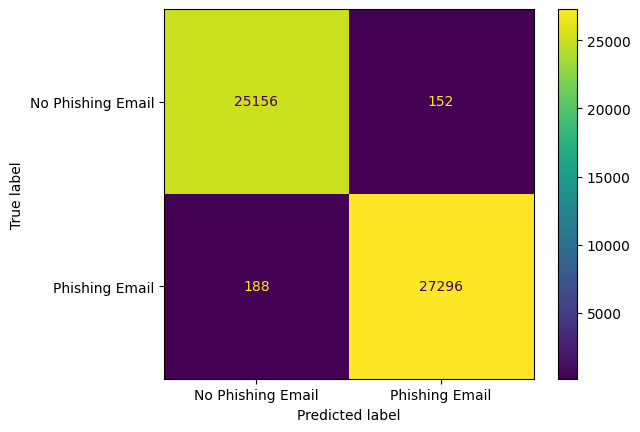

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.99      6301
   Phishing Email       0.99      0.99      0.99      6896

         accuracy                           0.99     13197
        macro avg       0.99      0.99      0.99     13197
     weighted avg       0.99      0.99      0.99     13197



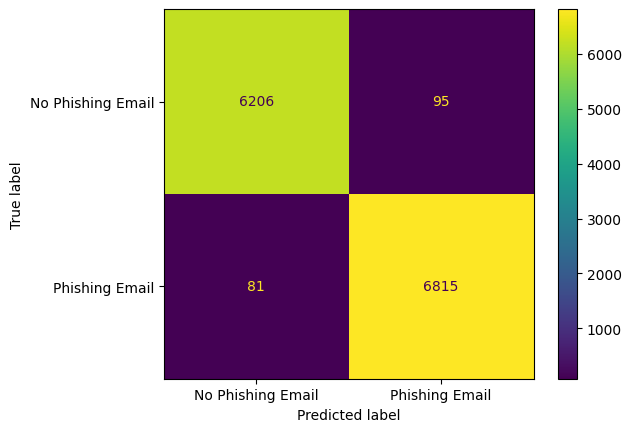

In [7]:
# Loop through all combinations of hyperparameters
for layers in layer_configs:
    for epochs in epochs_list:
        for min_delta in min_deltas:
            for patience in patiences:
                
                # Build the MLP model with specified layer configuration
                model = Sequential()
                
                # Add the input layer and the first hidden layer
                model.add(Dense(layers[0], activation='relu', input_shape=(X_train.shape[1],)))
                
                # Add any additional hidden layers
                for units in layers[1:]:
                    model.add(Dense(units, activation='relu'))
                
                # Add the output layer with sigmoid activation for binary classification
                model.add(Dense(1, activation='sigmoid'))

                # Compile the model with Adam optimizer and binary cross-entropy loss
                model.compile(optimizer=Adam(learning_rate=1e-3),
                              loss='binary_crossentropy',
                              metrics=['accuracy'])

                # Define EarlyStopping to stop training if val_loss doesn't improve
                early_stopping = EarlyStopping(
                    monitor='val_loss',       # Monitor validation loss
                    min_delta=min_delta,      # Minimum change to qualify as improvement
                    patience=patience,        # How many epochs to wait before stopping
                    restore_best_weights=True,# Restore weights from best epoch
                    verbose=1,
                    mode='min'                # Looking for minimum val_loss
                )

                # Define TimeStopping to stop training if it exceeds time limit
                time_stopping = TimeStopping(max_seconds=300)

                # Print current model configuration
                print(f"\nConfig: layers={layers}, epochs={epochs}, "
                      f"min_delta={min_delta}, patience={patience}")

                # Train the model with early stopping and time stopping callbacks
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs,
                    batch_size=32,
                    callbacks=[early_stopping, time_stopping],
                    verbose=2
                )

                # Capture the best validation loss achieved
                val_loss = min(history.history['val_loss'])
                print(f"Finished. Best val_loss={val_loss:.4f}, "
                      f"stopped at epoch {len(history.history['loss'])}\n")

                # Plot learning curves for loss and accuracy
                print("Print History")
                plot_history(history)
                
                # Evaluate on training set and print metrics
                print('Training Evaluation:\n')
                train_scores = eval_classification(model, X_train, y_train,
                                                   name=f'train {layers}-{epochs}-p{patience}-d{min_delta}',
                                                   labels=['No Phishing Email', 'Phishing Email'])

                # Evaluate on validation set and print metrics
                print('Validation Evaluation:\n')
                val_scores = eval_classification(model, X_val, y_val,
                                                 name=f'val {layers}-{epochs}-p{patience}-d{min_delta}',
                                                 labels=['No Phishing Email', 'Phishing Email'])

                # Combine train and validation scores for this run
                scores = pd.concat([train_scores, val_scores])
                all_scores.append(scores)

                # Track the best model based on validation F1 Score
                val_f1 = val_scores.iloc[0]['F1 Score']
                if val_f1 > best_f1:
                    best_f1 = val_f1
                    best_model = model
                    best_history = history
                    best_config = {
                        'layers': layers,
                        'epochs': epochs,
                        'min_delta': min_delta,
                        'patience': patience,
                        'val_f1_score': val_f1
                    }



🏆 Best Model Configuration:
layers: [128, 64]
epochs: 100
min_delta: 0.0
patience: 5
val_f1_score: 0.9877438537965044

📁 Best model saved as 'best_mlp_model.h5'
Results saved to mlp_model_results.csv

📊 Training History of Best Model:


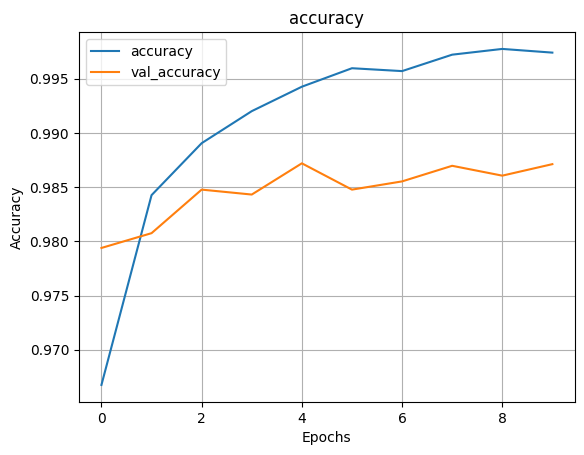

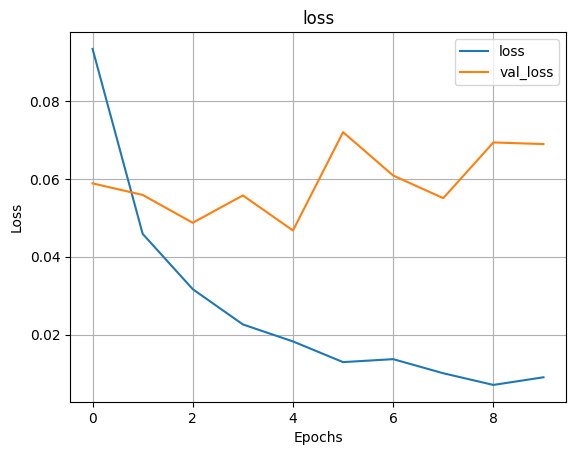

In [8]:
# Print best model config
print("\n🏆 Best Model Configuration:")
for k, v in best_config.items():
    print(f"{k}: {v}")

# Save best model
best_model.save('best_mlp_model.h5')
print("\n📁 Best model saved as 'best_mlp_model.h5'")

# Combine and save all scores
all_results_df = pd.concat(all_scores)
all_results_df.to_csv("mlp_model_results.csv", index=True)
print("Results saved to mlp_model_results.csv")

# Plot training history of the best model
print("\n📊 Training History of Best Model:")
plot_history(best_history)

In [9]:
# Filter only validation results
val_results = all_results_df[all_results_df.index.str.contains("val")]

# Sort by F1 Score in descending order
val_results_sorted = val_results.sort_values(by="F1 Score", ascending=False)

# Display the top results
print("🔝 Top Validation Results by F1 Score:")
display(val_results_sorted.head(10))

🔝 Top Validation Results by F1 Score:


,Accuracy,Precision,Recall,F1 Score,FPR,FNR
"val [128, 64]-100-p5-d0.0",0.987194,0.987959,0.987529,0.987744,0.013173,0.012471
"val [128, 64]-100-p3-d0.001",0.987043,0.987955,0.987239,0.987597,0.013173,0.012761
"val [256, 128, 64]-100-p5-d0.001",0.986664,0.986252,0.988254,0.987252,0.015077,0.011746
"val [256, 128, 64]-50-p3-d0.001",0.986436,0.987233,0.986804,0.987019,0.013966,0.013196
"val [128, 64]-100-p5-d0.001",0.986285,0.985258,0.988544,0.986898,0.016188,0.011456
"val [256, 128, 64]-50-p3-d0.0",0.985982,0.987081,0.986079,0.986580,0.014125,0.013921
"val [256, 128, 64]-100-p3-d0.0",0.985830,0.984404,0.988544,0.986470,0.017140,0.011456
val [64]-100-p3-d0.001,0.985830,0.985948,0.986949,0.986448,0.015394,0.013051
"val [256, 128, 64]-100-p5-d0.0",0.985527,0.986504,0.985789,0.986146,0.014760,0.014211
"val [256, 128, 64]-50-p5-d0.0",0.985300,0.982853,0.989124,0.985979,0.018886,0.010876
